# Charting Boulder: Who Balanced the Budget?
[Brian C. Keegan, Ph.D.](http://www.brianckeegan.com)  
June 2026; updated September 2026 for the 2027 budget

Released under a [MIT License](https://opensource.org/licenses/MIT).

---

This notebook analyzes responses to the **Balance Boulder's Budget** interactive published with the *Charting Boulder* column. Readers move sliders to close the \$6.3M gap in the city manager's recommended 2027 General Fund, and may answer an optional demographic survey adapted from the city's 2025 [Boulder Valley Comprehensive Plan (BVCP) survey](https://bouldervalleycompplan.net/). Each submission — every slider position, plus whichever survey questions the reader chose to answer — is stored anonymously in an external [Supabase](https://supabase.com/) database (hosted Postgres), not in Boulder Reporting Lab's WordPress/Newspack site. A response carries no name, email, account, IP address or browser fingerprint, and a reader's browser can add a row but never read one back. The project's `ARCHITECTURE.md` documents the full privacy model.

### What the column committed to in advance

The column published a hypothesis and four questions before the first response arrived. Each gets its own analysis below, and the pinned headline numbers in section 8 answer them in order. The measures and thresholds they need are fixed in this notebook before real responses exist; changing one after the data arrive is a deviation and should be reported as one. Everything else here is exploratory and says so.

| | In the column's words | Answered in |
|---|---|---|
| **Hypothesis** | "The demographics in the responses will skew toward homeowners, older residents and graduate degrees. These folks will be more likely to propose budgets that cut expenses rather than raising new revenue." | Sections 6 (the skew) and 4 (cuts over revenue) |
| **Q1** | "Cutting expenditures or raising revenue. How does the cut vs. tax split track demographics like housing, tenure, age, income?" | Sections 3 and 4 |
| **Q2** | "Drastic or incremental budget reforms. How many people tried to max out changes in revenue and expenditures versus incremental changes?" | Section 3 |
| **Q3** | "Consensus versus council. Which general fund and revenue levers drew the most support, set against the actual November ballot the council is now assembling?" | Section 5 |
| **Q4** | "Disagreement with recommendations. Which general fund and revenue options will have the greatest divergence from the budget recommended by staff?" | Section 5 |

The council settled the Nov. 3 ballot on Aug. 6, so section 5 uses the ballot as settled.

The analysis has five jobs, in order:

1. **Describe** who responded and how they closed the gap: the cut-versus-revenue split, drastic versus incremental changes, and (exploratory) what each budget's department changes would mean for city staffing.
2. **Cross-tabulate** budget choices against demographics, starting with the four the column named.
3. **Compare** readers' budgets with the November ballot and with the budget city staff recommended.
4. **Compare** the respondent pool to a statistically valid picture of Boulder, using the BVCP survey and the Census ACS as benchmarks.
5. **Reweight** the pool toward those benchmarks to *illustrate* what difference the demographic skew makes — while being explicit about what reweighting can and cannot fix.

> **The honesty spine of this notebook.** The respondents are a **self-selected** pool, not a probability sample. Reweighting can correct for *observed* demographic skew (too few renters, too many older homeowners, and so on). It **cannot** correct for *unobserved* selection bias — the people who choose to balance a city budget online differ from those who don't in ways no weight can capture. Every weighted number below is **illustrative, not an estimate of what Boulder thinks.**

### Libraries

This notebook uses only standard scientific-Python packages (pandas, numpy, scipy, matplotlib, seaborn), and the notebook itself needs no API keys. The reweighting section implements raking (iterative proportional fitting) directly, so there is no specialized survey package to install.

Set `STUB_MODE = True` (the default) to run end-to-end on a synthetic, deliberately skewed sample so the notebook executes before real responses exist. To run on live data, export the responses from Supabase with `pipeline/export-responses.py`, which writes `responses.csv` with one row per submission, then set `STUB_MODE = False` and point `RESPONSES_CSV` at that file. The export reads individual rows, so it needs the project's secret key: run it on a trusted machine, and never commit the key or the CSV (the repository's `.gitignore` already keeps `responses.csv` out). Both paths produce the same columns, so nothing downstream changes.

In [1]:
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats

pd.options.display.max_columns = 100

%matplotlib inline
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Reproducibility: every cell that uses randomness draws from this seed.
RNG_SEED = 2026
rng = np.random.default_rng(RNG_SEED)

# --- Run configuration -------------------------------------------------------
STUB_MODE = True                      # True = synthetic sample; False = live export
RESPONSES_CSV = 'responses.csv'       # written by pipeline/export-responses.py; read when STUB_MODE = False
N_STUB = 800                          # size of the synthetic pool
DROP_REPEATS = True                   # set aside a second budget from the same browser, as the column promised

## 1. Load the survey responses

### The data schema

Each submission is one flat row: the General Fund department sliders (`gf_*`), the locked sliders — each department's spending outside the General Fund (`fund_*`) — the revenue sliders (`rev_*`), and one column per survey item (`demo_*`). The department, locked, fee, property-tax and sales-tax sliders are percent changes in the range −25..25 from where each slider starts (for a department, its estimated status quo; see the next section), and `0` means the reader left that slider alone. Two work differently: `rev_marijuana` is the recreational marijuana tax rate a reader chose (0..10%, starting at today's 3.5%), and `rev_shift` is the dollars (in \$M, 0..5) a reader moved from the General Fund onto voter-dedicated funds.

The export also carries three columns the widget writes when a reader submits: `spend_change`, the signed \$M change in General Fund spending (negative is a net cut); `revenue_only`, the signed \$M of recurring revenue (negative is a net tax or fee cut); and `repeat_client`, which is true when the same browser had already submitted a budget. The notebook recomputes the two dollar totals from the slider positions with the widget's own numbers (next), so a synthetic run and a live run are measured the same way, and on live data it checks its arithmetic against the stored values. The column told readers that a second budget from the same browser is flagged and set aside; `repeat_client` is that flag.

These are the 2027 widget's columns (payload version 5); `pipeline/supabase/migrations/RUNBOOK-2027-sliders.md` records what changed from the 2026 widget. The column names match the Supabase table `public.contributions` one-to-one (its data dictionary is in the project's `ARCHITECTURE.md`, its definition in `pipeline/supabase/schema.sql`). The survey items are adapted from the city's 2025 [BVCP survey](https://bouldervalleycompplan.net/); several match its wording exactly (years in the valley, tenure, race, gender), while income, age, education, and disability were customized for this interactive and are **not** one-to-one comparable to the BVCP instrument.

In [2]:
# Canonical column lists — keep these in lockstep with the widget's data tables
# and with pipeline/export-responses.py.
GF_SLIDERS = ['gf_police', 'gf_genadmin', 'gf_fire', 'gf_hhs', 'gf_manager', 'gf_it',
              'gf_facilities', 'gf_finance', 'gf_parksrec', 'gf_attorney', 'gf_other']
# Each department's spending outside the General Fund (the 2027 locked section).
FUND_SLIDERS = ['fund_utilities', 'fund_transpo', 'fund_openspace', 'fund_hhs',
                'fund_parksrec', 'fund_facilities', 'fund_pds', 'fund_manager',
                'fund_climate', 'fund_fire', 'fund_other']
# rev_fees/rev_property/rev_sales: % change, −25..25. rev_marijuana: the tax rate,
# 0..10 (3.5 today). rev_shift: $M of costs moved onto dedicated funds, 0..5.
REV_COLS = ['rev_fees', 'rev_property', 'rev_sales', 'rev_marijuana', 'rev_shift']
DEMO_COLS = ['demo_years', 'demo_area', 'demo_employment', 'demo_commute', 'demo_student',
             'demo_education', 'demo_building', 'demo_tenure', 'demo_income',
             'demo_age', 'demo_race', 'demo_gender', 'demo_lgbtq', 'demo_disability']
# Written by the widget at submission: the signed $M totals and the repeat-browser flag.
STORED_COLS = ['spend_change', 'revenue_only', 'repeat_client']
SLIDER_COLS = GF_SLIDERS + FUND_SLIDERS

len(SLIDER_COLS), len(REV_COLS), len(DEMO_COLS), len(STORED_COLS)

(22, 5, 14, 3)

### The widget's numbers

Turning slider positions into dollars takes the numbers the widget uses. They are copied from `embed/src/boulder-budget-widget.jsx`, and `embed/PROVENANCE.md` traces each one to the city's budget documents. The formulas mirror the widget's:

- a department slider changes the department's starting point, its estimated 2027 status quo before the city's changes, by its percentage, and a locked slider changes that department's 2027 spending outside the General Fund;
- a fee or tax slider yields that percentage of its 2027 General Fund base (for sales tax, without the marijuana tax increase, which the marijuana slider counts);
- the marijuana tax adds \$0.206M for each point above today's 3.5%, and below 3.5% its \$1.0M falls in proportion to the rate;
- moving costs onto dedicated funds closes the gap dollar for dollar, but it is not revenue;
- a reader can submit only once the gap is closed, to within \$0.05M.

Every slider starts at the status quo, the budget with the \$6.3M gap, and the blue "proposed" ticks mark the recommended budget. A department's tick is its recommended 2027 amount, plus any cost the budget moves onto a dedicated fund, measured from its starting point; the marijuana tick is the proposed 5.5% rate; and the cost-shift tick is the \$566,128 of General Fund costs the city moves onto dedicated funds. Following every tick closes exactly the \$6.3M. The city doesn't publish each department's status quo, so the starting points are estimates: the recommended amounts with the city's itemized 2027 changes undone, plus the part of the gap the city doesn't itemize by department (about \$6.3M) spread in proportion to department size.

In [3]:
# From embed/src/boulder-budget-widget.jsx (payload v5), as of Oct. 1, 2026.
# Update these if the widget's numbers change, e.g. after the council adopts the budget.
GAP = 6.3                   # $M, the 2027 General Fund gap
BALANCE_TOL = 0.05          # the widget submits once the remaining gap is at most $0.05M

# General Fund departments, $M: where each slider starts (the estimated status quo),
# the recommended 2027 amount, General Fund costs the budget moves onto dedicated
# funds, and the restated 2026 budget.
GF_AMOUNT = {'police': 54.575, 'genadmin': 36.733, 'fire': 32.008, 'hhs': 13.793, 'manager': 12.164,
             'it': 11.652, 'facilities': 7.435, 'finance': 7.361, 'parksrec': 6.974,
             'attorney': 5.514, 'other': 18.175}
GF_RECOMMENDED = {'police': 54.246, 'genadmin': 35.612, 'fire': 30.968, 'hhs': 14.007, 'manager': 11.981,
                  'it': 10.680, 'facilities': 7.042, 'finance': 7.024, 'parksrec': 6.634,
                  'attorney': 5.518, 'other': 16.784}
GF_MOVED = {'fire': 0.180, 'parksrec': 0.036, 'hhs': 0.100, 'genadmin': 0.250}
GF_2026 = {'police': 50.204, 'genadmin': 38.436, 'fire': 29.129, 'hhs': 12.962, 'manager': 11.087,
           'it': 10.372, 'facilities': 7.153, 'finance': 6.881, 'parksrec': 6.490,
           'attorney': 5.067, 'other': 16.702}
GF_LABEL = {'police': 'Police', 'genadmin': 'General Government', 'fire': 'Fire-Rescue',
            'hhs': 'Housing & Human Services (GF share)', 'manager': "City Manager's Office",
            'it': 'Innovation & Technology', 'facilities': 'Facilities & Fleet (GF share)',
            'finance': 'Finance', 'parksrec': 'Parks & Recreation (GF share)',
            'attorney': "City Attorney's Office", 'other': 'Other General Fund departments'}
# Each department's spending outside the General Fund, 2027, $M (the locked section).
FUND_AMOUNT = {'utilities': 136.555, 'transpo': 60.028, 'openspace': 37.423, 'hhs': 35.715,
               'parksrec': 30.478, 'facilities': 16.946, 'pds': 16.232, 'manager': 7.448,
               'climate': 6.493, 'fire': 4.082, 'other': 0.705}
# Revenue: the 2027 General Fund bases ($M) of the percentage sliders, and the marijuana tax.
REV_BASE = {'fees': 10.973, 'property': 39.459, 'sales': 82.597}
MJ_NOW, MJ_BASE, MJ_PER_POINT, MJ_MAX = 3.5, 1.0, 0.206, 10.0
SHIFT_MAX = 5.0

# The blue "proposed" ticks: the recommended budget, measured from each starting point.
CITY_GF_PCT = {k: ((GF_RECOMMENDED[k] + GF_MOVED.get(k, 0)) / GF_AMOUNT[k] - 1) * 100 for k in GF_AMOUNT}
CITY_MJ_RATE = 5.5
CITY_SHIFT = 0.566

def marijuana_yield(rate):
    """$M change from today's rate, as the widget's revYield computes it."""
    rate = np.asarray(rate, dtype=float)
    return np.where(rate >= MJ_NOW, (rate - MJ_NOW) * MJ_PER_POINT, MJ_BASE * (rate / MJ_NOW - 1))

DOLLAR_COLS = ['spend_change_calc', 'revenue_calc', 'trapped_change', 'net_cuts', 'revenue_gain',
               'total_fix', 'rev_share', 'remaining', 'surplus']

def add_dollar_columns(df):
    """Each reader's budget in dollars, computed exactly as the widget computes it."""
    df['spend_change_calc'] = sum(df[f'gf_{k}'] / 100 * amt for k, amt in GF_AMOUNT.items())
    df['revenue_calc'] = (sum(df[f'rev_{k}'] / 100 * base for k, base in REV_BASE.items())
                          + marijuana_yield(df['rev_marijuana']))
    df['trapped_change'] = sum(df[f'fund_{k}'] / 100 * amt for k, amt in FUND_AMOUNT.items())
    df['net_cuts'] = (-df['spend_change_calc']).clip(lower=0)
    df['revenue_gain'] = df['revenue_calc'].clip(lower=0)
    df['total_fix'] = df['net_cuts'] + df['revenue_gain'] + df['rev_shift']
    # The widget's revenue share: the part of the fix that came from new revenue
    # (a net revenue cut counts as none). The shared tally averages it.
    df['rev_share'] = np.where(df['total_fix'] > 0, df['revenue_gain'] / df['total_fix'], 0.0)
    df['remaining'] = GAP + df['spend_change_calc'] - df['revenue_calc'] - df['rev_shift']
    df['surplus'] = -df['remaining']
    return df

{k: round(v, 1) for k, v in CITY_GF_PCT.items()}

{'police': -0.6,
 'genadmin': -2.4,
 'fire': -2.7,
 'hhs': 2.3,
 'manager': -1.5,
 'it': -8.3,
 'facilities': -5.3,
 'finance': -4.6,
 'parksrec': -4.4,
 'attorney': 0.1,
 'other': -7.7}

### Build the analysis frame

In `STUB_MODE` we synthesize a pool that is deliberately skewed the way a self-selected online sample of a college town tends to be — over-represented homeowners, older ages, and high education — so the representativeness and reweighting sections below have something real to correct. Every synthetic budget closes the gap, as a real submission must; a small cohort pushes one slider to its limit, so the drastic-versus-incremental question has something to find; and a few rows carry the repeat-browser flag. The generator is seeded, so the synthetic numbers are stable across runs. When `STUB_MODE = False`, the same columns are read from the Supabase export instead, with `ts` parsed as a UTC timestamp, and the synthetic block is skipped entirely. Either way, repeat budgets are then set aside.

In [4]:
# The response option lists below mirror the widget's DEMO table exactly so the
# synthetic data and the live export share a vocabulary.
OPTIONS = {
    'demo_years': ['5 years or less', '6-10 years', '11-20 years', 'More than 20 years', 'Prefer not to say'],
    'demo_area': ['North Boulder', 'Central Boulder', 'University Hill', 'South Boulder', 'University of Colorado',
                  'Southeast Boulder', 'East Boulder', 'Crossroads', 'Palo Park', 'Gunbarrel', 'Other',
                  'Outside the city', 'Prefer not to say'],
    'demo_employment': ['Working full time for pay', 'Working part time for pay',
                        'Unemployed, looking for paid work', 'Not retired, not looking for paid work',
                        'Fully retired', 'Prefer not to say'],
    'demo_commute': ['Drive (alone)', 'Carpool or rideshare', 'Bus or other transit', 'Bike', 'Scooter',
                     'Walk or roll', 'Mostly work or stay at home', 'Prefer not to say'],
    'demo_student': ['Yes, an undergraduate student', 'Yes, a graduate student', 'No', 'Prefer not to say'],
    'demo_education': ['No high school diploma', 'High school diploma', 'GED', 'Some college, no degree',
                       'Associate degree', "Bachelor's degree", "Master's degree",
                       'Professional degree (MD, JD, DDS)', 'Doctoral degree (PhD, EdD)', 'Prefer not to say'],
    'demo_building': ['Single-unit house detached from any other houses',
                      'Building with two or more homes (duplex, townhome, apartment or condominium)',
                      'Manufactured home', 'Other', 'Prefer not to say'],
    'demo_tenure': ['Own', 'Rent', 'Other', 'Prefer not to say'],
    'demo_income': ['Less than $25,000 per year', '$25,000 to $49,999 per year', '$50,000 to $99,999 per year',
                    '$100,000 to $149,999 per year', '$150,000 to $299,999 per year', '$300,000 per year or more',
                    'Prefer not to say'],
    'demo_age': ['18-24', '25-34', '35-44', '45-54', '55-64', '65 and over', 'Prefer not to say'],
    'demo_race': ['American Indian or Alaskan Native', 'Asian', 'Black or African American',
                  'Latine/Latinx/Hispanic', 'Middle Eastern or North African',
                  'Native Hawaiian or Pacific Islander', 'White', 'Other', 'Prefer not to say'],
    'demo_gender': ['Woman', 'Man', 'Non-binary/Genderqueer', 'Prefer to self-describe', 'Prefer not to say'],
    'demo_lgbtq': ['Yes', 'No', 'Prefer not to say'],
    'demo_disability': ['Yes, visible', 'Yes, invisible', 'Yes, visible and invisible',
                        'No', 'Prefer not to say'],
}

In [5]:
def _close_gap(df):
    """Top up any synthetic budget that falls short, as a real reader must before
    the widget will submit: owners mostly deepen a cut, renters mostly raise a fee
    or tax, one lever at a time and within each slider's limits."""
    orders = {
        True:  [('gf_genadmin', -1), ('gf_police', -1), ('rev_fees', 1), ('rev_property', 1), ('gf_other', -1), ('rev_sales', 1)],
        False: [('rev_property', 1), ('rev_fees', 1), ('gf_genadmin', -1), ('rev_sales', 1), ('gf_police', -1), ('gf_other', -1)],
    }
    owner = df['demo_tenure'].eq('Own')
    df = add_dollar_columns(df)
    for is_owner, order in orders.items():
        for col, sign in order:
            rows = df.index[(df['remaining'] > BALANCE_TOL) & (owner == is_owner)]
            if len(rows) == 0:
                break
            key = col.split('_', 1)[1]
            per_point = (GF_AMOUNT[key] if col.startswith('gf_') else REV_BASE[key]) / 100   # $M a point
            need = np.ceil(df.loc[rows, 'remaining'] / per_point)
            room = 25 - sign * df.loc[rows, col]                                            # points to the limit
            df.loc[rows, col] = df.loc[rows, col] + sign * np.minimum(need, room)
            df = add_dollar_columns(df)
    assert (df['remaining'] <= BALANCE_TOL).all(), 'a synthetic budget is still short'
    return df

def _synthesize_pool(n, rng):
    """A deliberately skewed self-selected pool (seeded). For STUB_MODE only."""
    # Skewed marginals: more owners, older, higher-educated than Boulder overall.
    skew = {
        'demo_tenure':    [0.62, 0.30, 0.03, 0.05],                       # Own-heavy
        'demo_age':       [0.06, 0.18, 0.20, 0.20, 0.18, 0.16, 0.02],     # older-skewed
        'demo_education': [0.00, 0.02, 0.01, 0.06, 0.04, 0.34, 0.30, 0.08, 0.13, 0.02],  # degree-heavy
        'demo_income':    [0.06, 0.10, 0.22, 0.22, 0.24, 0.12, 0.04],     # affluent-skewed
        'demo_years':     [0.18, 0.16, 0.24, 0.40, 0.02],
        'demo_gender':    [0.46, 0.46, 0.04, 0.01, 0.03],
        'demo_lgbtq':     [0.14, 0.80, 0.06],
    }
    data = {}
    for col, opts in OPTIONS.items():
        if col in skew:
            p = np.array(skew[col]); p = p / p.sum()
            data[col] = rng.choice(opts, size=n, p=p)
        elif col == 'demo_race':
            # Race is multi-select in the widget; most pick one, a few combine.
            base = ['White', 'Asian', 'Latine/Latinx/Hispanic', 'Black or African American',
                    'Other', 'Prefer not to say']
            wp = np.array([0.74, 0.10, 0.08, 0.02, 0.03, 0.03]); wp = wp / wp.sum()
            picks = rng.choice(base, size=n, p=wp)
            data[col] = picks
        else:
            p = np.ones(len(opts)) / len(opts)
            data[col] = rng.choice(opts, size=n, p=p)
    responses_df = pd.DataFrame(data)

    # Slider behavior, correlated with demographics so cross-tabs are non-trivial:
    # owners lean on cuts; renters and younger readers lean on revenue. Crucially,
    # only SOME readers pull each lever, so the top-line shares have real spread.
    owner = (responses_df['demo_tenure'] == 'Own').to_numpy()
    for col in SLIDER_COLS:
        responses_df[col] = 0
    # Department cuts: owners cut more often and deeper; not everyone cuts.
    def _maybe_cut(prob, lo, hi):
        hits = rng.random(n) < prob
        vals = rng.integers(lo, hi, n)
        return np.where(hits, vals, 0)
    responses_df['gf_police'] = np.where(owner, _maybe_cut(0.70, -20, -2), _maybe_cut(0.45, -12, -1))
    responses_df['gf_genadmin'] = _maybe_cut(0.60, -15, -1)
    responses_df['gf_it'] = _maybe_cut(0.30, -6, 7)
    responses_df['gf_hhs'] = np.where(owner, _maybe_cut(0.35, -8, 5), _maybe_cut(0.30, -2, 12))
    responses_df['gf_parksrec'] = _maybe_cut(0.30, -8, 4)
    # Revenue sources are percentage-change sliders (−25..25), like the GF
    # departments: a reader can raise, cut, or shift a tax. Most movers raise
    # fees/property; a distinct "shift" cohort trims the regressive sales tax and
    # makes it up on progressive property tax. The marijuana tax is a rate, and
    # moving costs onto dedicated funds is a dollar amount.
    responses_df['rev_fees'] = np.where(owner, _maybe_cut(0.45, -10, 13), _maybe_cut(0.60, -8, 17))
    responses_df['rev_property'] = np.where(owner, _maybe_cut(0.30, -8, 11), _maybe_cut(0.55, -5, 19))
    responses_df['rev_sales'] = np.where(owner, _maybe_cut(0.30, -13, 9), _maybe_cut(0.45, -10, 13))
    shift = rng.random(n) < 0.18                      # the regressive→progressive swap
    responses_df.loc[shift, 'rev_sales'] = rng.integers(-25, -4, shift.sum())
    responses_df.loc[shift, 'rev_property'] = rng.integers(8, 26, shift.sum())
    def _maybe_rev(prob, hi, dec):
        hits = rng.random(n) < prob
        vals = np.round(rng.uniform(0, hi, n), dec)
        return np.where(hits, vals, 0)
    responses_df['rev_shift'] = _maybe_rev(0.35, 5, 1)
    # The marijuana tax: most who move it raise it, and a few cut it.
    mj = rng.random(n)
    responses_df['rev_marijuana'] = np.select(
        [mj < 0.40, mj < 0.46],
        [rng.choice([4.0, 4.5, 5.0, 5.5, 6.0, 7.0, 8.0, 10.0], n), rng.choice([0.0, 1.5, 2.5, 3.0], n)],
        default=MJ_NOW)
    # Locked sliders: a meaningful minority try to move restricted money.
    responses_df['fund_utilities'] = _maybe_cut(0.22, -25, -2)
    responses_df['fund_parksrec'] = _maybe_cut(0.10, -25, 6)
    responses_df['fund_openspace'] = _maybe_cut(0.12, -20, 6)
    # A drastic minority pushes one lever to its limit.
    limits = {'gf_police': -25, 'gf_genadmin': -25, 'rev_property': 25, 'rev_fees': 25,
              'rev_sales': 25, 'rev_marijuana': MJ_MAX, 'rev_shift': SHIFT_MAX}
    drastic = np.flatnonzero(rng.random(n) < 0.12)
    for i, col in zip(drastic, rng.choice(list(limits), size=len(drastic))):
        responses_df.loc[i, col] = limits[col]
    # Every submitted budget closed the gap, so the synthetic ones do too.
    responses_df = _close_gap(responses_df)
    int_cols = SLIDER_COLS + ['rev_fees', 'rev_property', 'rev_sales']
    responses_df[int_cols] = responses_df[int_cols].astype(int)
    # What the export carries besides the sliders: the widget's stored totals,
    # rounded to $0.01M as the widget rounds them, and the repeat-browser flag.
    responses_df['spend_change'] = responses_df['spend_change_calc'].round(2)
    responses_df['revenue_only'] = responses_df['revenue_calc'].round(2)
    responses_df['repeat_client'] = rng.random(n) < 0.03
    responses_df['scenario'] = '2027'
    responses_df['ts'] = pd.Timestamp('2026-09-30') + pd.to_timedelta(rng.integers(0, 14*24*60, n), unit='m')
    return responses_df.drop(columns=DOLLAR_COLS)

if STUB_MODE:
    responses_df = _synthesize_pool(N_STUB, rng)
    print(f'STUB_MODE: synthesized {len(responses_df):,} responses (seed={RNG_SEED}).')
else:
    # The Supabase export (pipeline/export-responses.py). `ts` is the database's
    # insert time, which a server-side trigger sets, so a reader's clock cannot move it.
    responses_df = pd.read_csv(RESPONSES_CSV)
    responses_df['ts'] = pd.to_datetime(responses_df['ts'], utc=True, format='ISO8601')
    if 'repeat_client' not in responses_df:
        print('This export has no repeat_client column; re-run pipeline/export-responses.py.')
        responses_df['repeat_client'] = False
    responses_df['repeat_client'] = responses_df['repeat_client'].astype(str).str.lower().isin(['true', 't', '1'])
    print(f'Loaded {len(responses_df):,} responses from {RESPONSES_CSV}.')

# The column told readers that a second budget from the same browser is set aside.
n_repeats = int(responses_df['repeat_client'].sum())
if DROP_REPEATS:
    responses_df = responses_df[~responses_df['repeat_client']].reset_index(drop=True)
print(f'Repeat budgets from the same browser: {n_repeats:,} '
      f'({"set aside" if DROP_REPEATS else "kept"}); analyzing {len(responses_df):,}.')

responses_df.head()

STUB_MODE: synthesized 800 responses (seed=2026).
Repeat budgets from the same browser: 36 (set aside); analyzing 764.


,demo_years,demo_area,demo_employment,demo_commute,demo_student,demo_education,demo_building,demo_tenure,demo_income,demo_age,demo_race,demo_gender,demo_lgbtq,demo_disability,gf_police,gf_genadmin,gf_fire,gf_hhs,gf_manager,gf_it,gf_facilities,gf_finance,gf_parksrec,gf_attorney,gf_other,fund_utilities,fund_transpo,fund_openspace,fund_hhs,fund_parksrec,fund_facilities,fund_pds,fund_manager,fund_climate,fund_fire,fund_other,rev_fees,rev_property,rev_sales,rev_shift,rev_marijuana,spend_change,revenue_only,repeat_client,scenario,ts
0,5 years or less,Other,Fully retired,Scooter,"Yes, an undergraduate student","Doctoral degree (PhD, EdD)","Building with two or more homes (duplex, townh...",Own,"Less than $25,000 per year",45-54,White,Man,No,No,-8,-10,0,0,0,-4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11,-12,3.6,3.5,-8.51,-5.57,False,2027,2026-10-08 03:40:00
1,More than 20 years,Gunbarrel,Working full time for pay,Prefer not to say,Prefer not to say,Bachelor's degree,"Building with two or more homes (duplex, townh...",Own,"$50,000 to $99,999 per year",Prefer not to say,White,Woman,No,Prefer not to say,-7,-10,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,4.5,-7.22,0.21,False,2027,2026-10-02 04:10:00
2,11-20 years,Other,Working part time for pay,Carpool or rideshare,No,"Doctoral degree (PhD, EdD)",Manufactured home,Own,"$50,000 to $99,999 per year",35-44,White,Man,Yes,"Yes, invisible",-17,-2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11,0,0,0.0,3.5,-10.01,1.21,False,2027,2026-10-13 19:20:00
3,11-20 years,Southeast Boulder,Prefer not to say,Mostly work or stay at home,No,GED,Manufactured home,Rent,"$150,000 to $299,999 per year",65 and over,White,Man,No,No,-12,-14,0,0,0,0,0,0,0,0,0,-15,0,0,0,0,0,0,0,0,0,0,7,-5,-2,0.0,10.0,-11.69,-1.52,False,2027,2026-10-12 20:03:00
4,11-20 years,University Hill,Working full time for pay,Mostly work or stay at home,"Yes, a graduate student","Professional degree (MD, JD, DDS)",Other,Own,"$100,000 to $149,999 per year",45-54,Prefer not to say,Woman,No,"Yes, visible",0,-17,0,3,0,-5,0,0,0,0,0,0,0,-17,0,0,0,0,0,0,0,0,0,0,0,0.0,3.5,-6.41,0.00,False,2027,2026-10-07 17:10:00


### Integrity checks

Before any number is reported, confirm the frame is shaped the way the schema promises: the expected columns are present, every slider sits inside its range, every retained row answered at least one survey question, and every budget closed the gap. The widget enforces the last two before it submits, and the database's insert policy rejects any row without a survey answer, so a violation here means a bad export, not a real respondent. On live data the notebook's dollar arithmetic is also checked against the totals the widget stored. A mismatch means the widget's numbers changed while responses were coming in (after the council adopts the budget, for example), and those rows need a look before anything is quoted.

In [6]:
# Every schema column is present.
_expected = set(SLIDER_COLS + REV_COLS + DEMO_COLS)
_missing = _expected - set(responses_df.columns)
assert not _missing, f'Missing expected columns: {sorted(_missing)}'

# The department, locked, fee and tax sliders are percentage changes within the
# widget's −25..25 bounds. The marijuana tax is a rate, and moving costs onto
# dedicated funds is a dollar amount; each has its own range.
_pct_cols = SLIDER_COLS + ['rev_fees', 'rev_property', 'rev_sales']
for _c in _pct_cols:
    assert responses_df[_c].between(-25, 25).all(), f'{_c} has out-of-range values'
assert responses_df['rev_marijuana'].between(0, MJ_MAX).all(), 'rev_marijuana outside 0..10'
assert responses_df['rev_shift'].between(0, SHIFT_MAX).all(), 'rev_shift outside 0..5 ($M)'

# Power-of-two truncation watch (an Excel round-trip would betray itself here).
assert len(responses_df) not in (256, 16384, 65536, 1048576), 'Suspicious row count — check for truncation'

# At least one demographic answer per row (the interactive requires it to submit).
_answered = responses_df[DEMO_COLS].notna().sum(axis=1)
assert (_answered >= 1).all(), f'{(_answered < 1).sum()} rows answered no survey questions'

# Every budget closed the gap. Check the widget's stored totals when the export
# has them (rounded to $0.01M, hence the slack), and compare the notebook's arithmetic.
responses_df = add_dollar_columns(responses_df)
if {'spend_change', 'revenue_only'} <= set(responses_df.columns):
    _mismatch = (((responses_df['spend_change_calc'] - responses_df['spend_change']).abs() > 0.011)
                 | ((responses_df['revenue_calc'] - responses_df['revenue_only']).abs() > 0.011))
    print(f"Rows whose recomputed dollars differ from the widget's stored totals: {_mismatch.sum():,}")
    _remaining = GAP + responses_df['spend_change'] - responses_df['revenue_only'] - responses_df['rev_shift']
    _tol = BALANCE_TOL + 0.02
else:
    _remaining, _tol = responses_df['remaining'], BALANCE_TOL
assert (_remaining <= _tol).all(), f'{(_remaining > _tol).sum()} budgets do not close the gap'

print('Integrity checks passed:', len(responses_df), 'rows,',
      len(_pct_cols) + 2, 'sliders,', len(DEMO_COLS), 'survey items.')

Rows whose recomputed dollars differ from the widget's stored totals: 0
Integrity checks passed: 764 rows, 27 sliders, 14 survey items.


## 2. Basic counts and ranges

### How many responses, and how complete?

The first thing a reader of the column will ask is how big the pool is and how much of the optional survey people actually filled in. `n_responses` and the completion figures below are pinned variables — every count the column quotes traces back to one of them.

In [7]:
n_responses = len(responses_df)

# Completion: how many of the 14 survey items each respondent answered.
answers_per_person_s = responses_df[DEMO_COLS].notna().sum(axis=1)
median_answers = int(answers_per_person_s.median())
pct_answered_all = (answers_per_person_s == len(DEMO_COLS)).mean()

print(f'Responses:                 {n_responses:,}')
print(f'Survey items (max):        {len(DEMO_COLS)}')
print(f'Median items answered:     {median_answers}')
print(f'Share answering all items: {pct_answered_all:.1%}')
print(f'Date range:                {responses_df["ts"].min():%Y-%m-%d} to {responses_df["ts"].max():%Y-%m-%d}')


Responses:                 764
Survey items (max):        14
Median items answered:     14
Share answering all items: 100.0%
Date range:                2026-09-30 to 2026-10-13


### Per-item response counts

Item non-response matters for everything downstream: a demographic answered by only a handful of people cannot carry a cross-tab or a weighting cell. This table is the denominator audit for the rest of the notebook.

In [8]:
item_counts_df = pd.DataFrame({
    'answered': responses_df[DEMO_COLS].notna().sum(),
    'answered_pct': responses_df[DEMO_COLS].notna().mean(),
    'prefer_not_pct': (responses_df[DEMO_COLS] == 'Prefer not to say').mean(),
})
item_counts_df['answered_pct'] = item_counts_df['answered_pct'].round(3)
item_counts_df['prefer_not_pct'] = item_counts_df['prefer_not_pct'].round(3)
item_counts_df.sort_values('answered', ascending=False)


,answered,answered_pct,prefer_not_pct
demo_years,764,1.0,0.021
demo_area,764,1.0,0.073
demo_employment,764,1.0,0.173
demo_commute,764,1.0,0.116
demo_student,764,1.0,0.229
demo_education,764,1.0,0.018
demo_building,764,1.0,0.234
demo_tenure,764,1.0,0.056
demo_income,764,1.0,0.029
demo_age,764,1.0,0.026


### Slider ranges

A quick describe() on the slider columns confirms the inputs behaved — the percentage sliders within ±25, the marijuana tax rate within 0–10% and the cost shift within \$0–5M — and shows where readers actually pushed. Columns whose min and max are both near zero are sliders most readers left alone.

In [9]:
slider_summary_df = responses_df[SLIDER_COLS + REV_COLS].describe().T[['mean', 'std', 'min', 'max']].round(2)
slider_summary_df


,mean,std,min,max
gf_police,-6.86,6.90,-25.0,0.0
gf_genadmin,-9.49,7.82,-25.0,0.0
gf_fire,0.00,0.00,0.0,0.0
gf_hhs,-0.04,2.86,-8.0,11.0
gf_manager,0.00,0.00,0.0,0.0
gf_it,0.00,1.97,-6.0,6.0
gf_facilities,0.00,0.00,0.0,0.0
gf_finance,0.00,0.00,0.0,0.0
gf_parksrec,-0.75,2.19,-8.0,3.0
gf_attorney,0.00,0.00,0.0,0.0


## 3. How readers closed the gap (Q1, Q2)

### Cuts vs. revenue: how did people close the gap? (Q1)

The widget offers three ways to close the gap: cut General Fund spending; change revenue, where the fee, property-tax, sales-tax and marijuana-tax sliders each move both ways; or move General Fund costs onto voter-dedicated funds. It offers no one-time reserves, because the gap recurs every year.

Using the widget's numbers, each budget becomes dollars: net cuts, new recurring revenue and costs shifted. The column's "cut vs. tax split" is the **revenue share**, the part of a reader's fix that came from new revenue, computed exactly as the widget's shared tally computes it (a net revenue cut counts as none). A reader is **mostly revenue** when that share is at least one half. `used_revenue` and `used_shift` are the flags the widget stores: `used_revenue` means the reader's revenue changes add up to a net gain, so a reader who raised the property tax but cut the sales tax by more did not use revenue. `any_cut` means at least one department slider went below zero.

In [10]:
# Dollars per reader, computed as the widget computes them (see "The widget's numbers").
responses_df = add_dollar_columns(responses_df)

# The column's measures (Q1).
responses_df['any_cut'] = (responses_df[GF_SLIDERS] < 0).any(axis=1)
responses_df['used_revenue'] = responses_df['revenue_calc'] > 0.01      # the widget's used_revenue
responses_df['used_shift'] = responses_df['rev_shift'] > 0              # the widget's used_shift
responses_df['mostly_revenue'] = responses_df['rev_share'] >= 0.5
responses_df['main_lever'] = (responses_df[['net_cuts', 'revenue_gain', 'rev_shift']].idxmax(axis=1)
                              .map({'net_cuts': 'cuts', 'revenue_gain': 'revenue', 'rev_shift': 'moving costs'}))

# Lever by lever (exploratory). The database still stores used_vote ("raised the
# property or sales tax"), although the widget no longer frames these as vote taxes.
responses_df['used_vote'] = (responses_df['rev_property'] > 0) | (responses_df['rev_sales'] > 0)
responses_df['raised_fees'] = responses_df['rev_fees'] > 0
responses_df['raised_marijuana'] = responses_df['rev_marijuana'] > MJ_NOW
responses_df['cut_a_tax'] = ((responses_df[['rev_fees', 'rev_property', 'rev_sales']] < 0).any(axis=1)
                             | (responses_df['rev_marijuana'] < MJ_NOW))
# A reader "shifts" the mix when they raise one of the property and sales taxes
# while cutting the other, e.g. trimming the sales tax and leaning on property tax.
responses_df['shifted_revenue'] = (
    ((responses_df['rev_property'] > 0) & (responses_df['rev_sales'] < 0)) |
    ((responses_df['rev_sales'] > 0) & (responses_df['rev_property'] < 0))
)

topline = {
    'made at least one cut': responses_df['any_cut'].mean(),
    'raised net new revenue': responses_df['used_revenue'].mean(),
    'got at least half their fix from revenue': responses_df['mostly_revenue'].mean(),
    'moved costs onto dedicated funds': responses_df['used_shift'].mean(),
    'raised the marijuana tax': responses_df['raised_marijuana'].mean(),
    'raised the property or sales tax': responses_df['used_vote'].mean(),
    'cut at least one fee or tax': responses_df['cut_a_tax'].mean(),
    'traded sales tax for property tax, or back': responses_df['shifted_revenue'].mean(),
}
topline_s = pd.Series(topline).sort_values(ascending=False)
mean_rev_share = responses_df['rev_share'].mean()
print(f'Mean revenue share of the fix: {mean_rev_share:.1%}')
print('Share of respondents who...')
for label, share in topline_s.items():
    print(f'  {share:5.1%}  {label}')
print('Largest part of each fix:', responses_df['main_lever'].value_counts(normalize=True).round(3).to_dict())

Mean revenue share of the fix: 22.5%
Share of respondents who...
  95.8%  made at least one cut
  60.1%  raised net new revenue
  58.6%  raised the property or sales tax
  53.3%  cut at least one fee or tax
  40.8%  raised the marijuana tax
  34.9%  moved costs onto dedicated funds
  28.9%  traded sales tax for property tax, or back
  19.4%  got at least half their fix from revenue
Largest part of each fix: {'cuts': 0.753, 'revenue': 0.209, 'moving costs': 0.038}


### Which departments took the deepest cuts?

Averaging each General Fund slider across all respondents shows where the pool was willing to cut and where it protected spending. The chart shows the average change in dollars, so a 10% cut to Police (\$5.6M) counts for more than a 10% cut to Finance (\$0.7M). The table adds the share of readers who cut or raised each department, and the share of cutters whose deepest cut, in dollars, fell there, which is what the widget's shared tally reports.

,label,share_cut,share_raised,mean_pct,mean_dollars,share_top_cut
police,Police,0.628,0.000,-6.861,-3.745,0.488
genadmin,General Government,0.793,0.000,-9.495,-3.488,0.495
parksrec,Parks & Recreation (GF share),0.188,0.068,-0.750,-0.052,0.007
hhs,Housing & Human Services (GF share),0.171,0.156,-0.035,-0.005,0.001
manager,City Manager's Office,0.000,0.000,0.000,0.000,0.000
facilities,Facilities & Fleet (GF share),0.000,0.000,0.000,0.000,0.000
finance,Finance,0.000,0.000,0.000,0.000,0.000
fire,Fire-Rescue,0.000,0.000,0.000,0.000,0.000
other,Other General Fund departments,0.000,0.000,0.000,0.000,0.000
attorney,City Attorney's Office,0.000,0.000,0.000,0.000,0.000


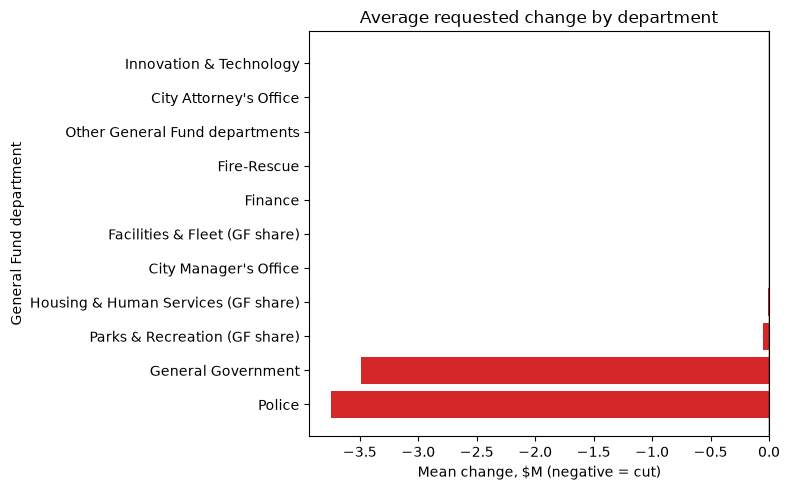

In [11]:
dept_df = pd.DataFrame({
    'label': pd.Series(GF_LABEL),
    'share_cut': pd.Series({k: (responses_df[f'gf_{k}'] < 0).mean() for k in GF_AMOUNT}),
    'share_raised': pd.Series({k: (responses_df[f'gf_{k}'] > 0).mean() for k in GF_AMOUNT}),
    'mean_pct': pd.Series({k: responses_df[f'gf_{k}'].mean() for k in GF_AMOUNT}),
    'mean_dollars': pd.Series({k: (responses_df[f'gf_{k}'] / 100 * amt).mean() for k, amt in GF_AMOUNT.items()}),
})
# Each reader's deepest cut in dollars (the widget stores it as top_cut).
cut_dollars_df = pd.DataFrame({k: -responses_df[f'gf_{k}'] / 100 * amt for k, amt in GF_AMOUNT.items()})
responses_df['top_cut'] = cut_dollars_df.idxmax(axis=1).where(cut_dollars_df.max(axis=1) > 0.01)
dept_df['share_top_cut'] = responses_df['top_cut'].value_counts(normalize=True).reindex(dept_df.index).fillna(0)
dept_df = dept_df.sort_values('mean_dollars')

f, ax = plt.subplots(figsize=(8, 5))
colors = ['tab:red' if v < 0 else 'tab:blue' for v in dept_df['mean_dollars']]
ax.barh(dept_df['label'], dept_df['mean_dollars'], color=colors)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Mean change, $M (negative = cut)')
ax.set_ylabel('General Fund department')
ax.set_title('Average requested change by department')
plt.tight_layout()
dept_df.round(3)

### The locked-fund lesson: did people try to raid restricted money?

The interactive's argument is that most of the budget is ring-fenced. One behavioral check: how often readers moved a *locked* slider — a department's spending outside the General Fund, capital included — whose savings can't reach the gap. A high rate is itself a finding — it suggests the constraint isn't obvious until the tool shows you.

In [12]:
moved_locked_s = (responses_df[FUND_SLIDERS] != 0).any(axis=1)
pct_moved_locked = moved_locked_s.mean()
pct_moved_utilities = (responses_df['fund_utilities'] != 0).mean()
print(f'Moved at least one locked slider:        {pct_moved_locked:.1%}')
print(f'Moved Utilities (rate-funded, largest):  {pct_moved_utilities:.1%}')
print(f'Mean locked change among them:           {responses_df.loc[moved_locked_s, "trapped_change"].mean():+.1f} $M, none of it reaching the gap')

Moved at least one locked slider:        36.6%
Moved Utilities (rate-funded, largest):  22.6%
Mean locked change among them:           -13.9 $M, none of it reaching the gap


### Drastic or incremental? (Q2)

The column asked how many readers tried to max out changes in revenue and spending, and how many made incremental changes. The definitions, fixed here before any real responses:

- A slider is **maxed out** when it sits at its limit: −25% or +25% for a department, fee or tax slider; 0% or the 10% cap for the marijuana tax; \$5M for moving costs. The locked sliders don't count, because they can't change the gap.
- A reader is **drastic** when they maxed out at least one slider.
- A reader is **incremental** when no slider they moved went more than 10 points from where it started (for the marijuana tax, 2 points of tax rate; for moving costs, \$1M).
- Everyone else made **large** changes without hitting a limit.

The **surplus** is how far past the gap a reader went. The widget accepts a budget as soon as the gap is closed, so a large surplus belongs to a reader who kept going.

In [13]:
PCT_SLIDERS = GF_SLIDERS + ['rev_fees', 'rev_property', 'rev_sales']
INCREMENTAL_PCT, INCREMENTAL_MJ, INCREMENTAL_SHIFT = 10, 2.0, 1.0

maxed_df = pd.concat([responses_df[PCT_SLIDERS].abs() >= 25,
                      responses_df['rev_marijuana'].isin([0, MJ_MAX]).rename('rev_marijuana'),
                      (responses_df['rev_shift'] >= SHIFT_MAX).rename('rev_shift')], axis=1)
responses_df['n_maxed'] = maxed_df.sum(axis=1)
responses_df['maxed_out'] = responses_df['n_maxed'] > 0
responses_df['n_moved'] = ((responses_df[PCT_SLIDERS] != 0).sum(axis=1)
                           + (responses_df['rev_marijuana'] != MJ_NOW).astype(int)
                           + (responses_df['rev_shift'] > 0).astype(int))
_small = ((responses_df[PCT_SLIDERS].abs() <= INCREMENTAL_PCT).all(axis=1)
          & ((responses_df['rev_marijuana'] - MJ_NOW).abs() <= INCREMENTAL_MJ)
          & (responses_df['rev_shift'] <= INCREMENTAL_SHIFT))
responses_df['reform_style'] = np.select([responses_df['maxed_out'], _small], ['drastic', 'incremental'], default='large')

style_s = responses_df['reform_style'].value_counts(normalize=True).reindex(['incremental', 'large', 'drastic']).fillna(0)
print('Share of readers by reform style:')
for k, v in style_s.items():
    print(f'  {v:5.1%}  {k}')
print(f'Median sliders moved:          {responses_df["n_moved"].median():.0f}')
print(f'Median surplus past the gap:   ${responses_df["surplus"].median():.2f}M')
print(f'Closed the gap twice over:     {(responses_df["surplus"] >= GAP).mean():.1%}')
print('Sliders most often maxed out (share of readers):')
maxed_df.mean().sort_values(ascending=False).head(5).round(3)

Share of readers by reform style:
   8.8%  incremental
  63.5%  large
  27.7%  drastic
Median sliders moved:          5
Median surplus past the gap:   $0.46M
Closed the gap twice over:     17.4%
Sliders most often maxed out (share of readers):


rev_property     0.093
gf_genadmin      0.090
rev_marijuana    0.076
rev_fees         0.065
rev_sales        0.024
dtype: float64

### Exploratory: budget types, and what they would mean for city staffing

This is not one of the column's four questions. Its definitions are fixed here, before any real responses, so it is exploratory but specified in advance.

**Budget types.** Every budget gets exactly one:

- **Slash:** a net cut to General Fund departments of more than 5% of their starting point, about \$10.3M, which is more than one and a half times the gap. A budget that cuts that deep is a slash budget whatever else the reader did.
- Otherwise, by the largest part of the fix: **cut-led**, **revenue-led** or **shift-led**, for moving costs onto dedicated funds.

**Clusters.** As a check on those hand-drawn lines, k-means sorts the budgets into four clusters by their dollar change on every General Fund and revenue lever. The run is seeded, so it finds the same clusters every time, and each cluster is named for the two levers that define it. The clusters describe the pool; they are not a typology to test.

**Position-equivalents.** Each budget's department changes are converted into General Fund positions, in full-time equivalents (FTE), two ways:

- **In proportion**, the central estimate: a department's change falls on staff in proportion to the share of its General Fund budget that pays for staff, so a 10% cut from a department's starting point removes about 10% of its General Fund positions.
- **Staff only**, an upper bound: the whole change falls on staff, at the department's average cost per position.

Both measure how large a budget's department changes are in staffing terms. Neither is a layoff forecast: a department can cut vacancies, overtime, contracts or programs instead, and the starting points are estimates. The city's own plan, measured the same way, is the reference.

#### The staffing inputs

| Slider | General Fund, 2027 | Personnel | Personnel share | General Fund positions (FTE) | Cost per position |
|---|---:|---:|---:|---:|---:|
| Police | \$54.2M | \$42.8M | 78.9% | 273.0 | \$156,791 |
| General Government | \$35.6M | \$2.0M | 5.5% | 0 | |
| Fire-Rescue | \$31.0M | \$24.5M | 79.0% | 128.6 | \$190,276 |
| Housing & Human Services | \$14.0M | \$5.4M | 38.5% | 40.7 | \$132,634 |
| City Manager's Office | \$12.0M | \$5.9M | 49.2% | 36.2 | \$162,649 |
| Innovation & Technology | \$10.7M | \$9.3M | 87.2% | 54.9 | \$169,611 |
| Facilities & Fleet | \$7.0M | \$3.8M | 53.6% | 33.6 | \$112,384 |
| Finance | \$7.0M | \$5.7M | 80.7% | 43.2 | \$131,307 |
| Parks & Recreation | \$6.6M | \$4.6M | 68.8% | 38.2 | \$119,535 |
| City Attorney's Office | \$5.5M | \$5.1M | 92.3% | 26.7 | \$190,818 |
| Other General Fund departments | \$16.8M | \$13.3M | 79.5% | 110.2 | \$121,059 |
| **Total** | **\$200.5M** | **\$122.3M** | **61.0%** | **785.3** | |

- **Personnel spending** comes from the city's transparency portal, [report 188635](https://cityofboulderco.opengov.com/transparency/#/188635/accountType=expenses&embed=table), the dataset behind the Budget in Brief's tables: General Fund only, by cost center, expense type Personnel, 2027 Budget. In the same view, the departments' General Fund totals reproduce the Fund Financial's \$200,496,242 to the dollar.
- **Positions** start from the Budget in Brief's staffing levels by department ("2027 Rec. Staffing," all funds). A department's average cost per position is its personnel spending in all funds, less seasonal and temporary staff at the Budget in Brief's own rate (\$18.17 an hour for 2,080 hours), divided by its positions. Its General Fund positions are its General Fund personnel spending divided by that average, capped at its total. The "Other" row adds up its eight departments.
- **General Government** has no positions in the staffing table. Its \$2.0M of personnel spending is citywide, so cutting it moves no positions here.
- **The city's plan in its own terms:** the staffing table eliminates 24.10 positions citywide, 13.10 of them filled, adds 26.50 and holds 8.50 vacant, a net change of +2.40.

In [14]:
# Staffing inputs by slider, 2027 recommended budget ($M and FTE); see the table above.
GF_PERSONNEL = {'police': 42.804, 'genadmin': 1.971, 'fire': 24.471, 'hhs': 5.400, 'manager': 5.896,
                'it': 9.314, 'facilities': 3.776, 'finance': 5.672, 'parksrec': 4.562,
                'attorney': 5.095, 'other': 13.341}
GF_FTE = {'police': 273.0, 'genadmin': 0.0, 'fire': 128.6, 'hhs': 40.7, 'manager': 36.2,
          'it': 54.9, 'facilities': 33.6, 'finance': 43.2, 'parksrec': 38.2,
          'attorney': 26.7, 'other': 110.2}
CITY_STAFFING = {'eliminated': 24.10, 'eliminated_filled': 13.10, 'added': 26.50, 'held_vacant': 8.50}   # citywide
# $M: the part of the gap the city doesn't itemize by department, which the starting points
# spread in proportion to each department's recommended budget (embed/PROVENANCE.md).
GAP_UNITEMIZED = 6.307

def position_equivalents(pct_df, staff_only=False):
    """Change in General Fund positions from each department's starting point, one column per
    department. In proportion, positions move with the department's General Fund budget; staff
    only, every dollar of the change is a dollar of staff, at the department's cost per position."""
    out = {}
    for k, base in GF_AMOUNT.items():
        dollars = pct_df[f'gf_{k}'] / 100 * base                        # $M from the starting point
        per_million = GF_FTE[k] / (GF_PERSONNEL[k] if staff_only else GF_RECOMMENDED[k])
        out[k] = (dollars * per_million).clip(lower=-GF_FTE[k] * base / GF_RECOMMENDED[k])
    return pd.DataFrame(out, index=pct_df.index)

print(f'General Fund positions: {sum(GF_FTE.values()):.1f} FTE, paid from ${sum(GF_PERSONNEL.values()):.1f}M '
      f'of personnel spending in a ${sum(GF_RECOMMENDED.values()):.1f}M General Fund.')

General Fund positions: 785.3 FTE, paid from $122.3M of personnel spending in a $200.5M General Fund.


In [15]:
from scipy.cluster.vq import kmeans2

# Budget types (exploratory, fixed before any real responses).
SLASH_SHARE = 0.05
SLASH_CUT = SLASH_SHARE * sum(GF_AMOUNT.values())                       # about $10.3M of net department cuts
TYPE_ORDER = ['slash', 'cut-led', 'revenue-led', 'shift-led']
responses_df['budget_type'] = np.where(
    responses_df['net_cuts'] > SLASH_CUT, 'slash',
    responses_df['main_lever'].map({'cuts': 'cut-led', 'revenue': 'revenue-led', 'moving costs': 'shift-led'}))

# Clusters (exploratory): k-means on each reader's dollar change, lever by lever, seeded.
LEVER_LABEL = {**{f'gf_{k}': v for k, v in GF_LABEL.items()}, 'rev_fees': 'Fees', 'rev_property': 'Property tax',
               'rev_sales': 'Sales tax', 'rev_marijuana': 'Marijuana tax', 'rev_shift': 'Moving costs'}
lever_dollars_df = pd.DataFrame({
    **{f'gf_{k}': responses_df[f'gf_{k}'] / 100 * amt for k, amt in GF_AMOUNT.items()},
    **{f'rev_{k}': responses_df[f'rev_{k}'] / 100 * base for k, base in REV_BASE.items()},
    'rev_marijuana': marijuana_yield(responses_df['rev_marijuana']),
    'rev_shift': responses_df['rev_shift'].astype(float)}, index=responses_df.index)
N_CLUSTERS = 4
centroids, cluster_ids = kmeans2(lever_dollars_df.to_numpy(float), N_CLUSTERS, minit='++',
                                 rng=np.random.default_rng(RNG_SEED))
assert len(set(cluster_ids)) == N_CLUSTERS, 'k-means left a cluster empty'

# Number the clusters from deepest mean net cut to shallowest; name each for its two biggest levers.
rank = responses_df.groupby(cluster_ids)['net_cuts'].mean().sort_values(ascending=False).index
renumber = {old: new for new, old in enumerate(rank, start=1)}
responses_df['cluster'] = pd.Series(cluster_ids, index=responses_df.index).map(renumber)
centroid_df = pd.DataFrame(centroids, columns=lever_dollars_df.columns).rename(index=renumber).sort_index()

def describe_centroid(row, n=2):
    top = row.abs().sort_values(ascending=False).head(n).index
    return ', '.join(f"{LEVER_LABEL[c]} {'+' if row[c] >= 0 else '−'}${abs(row[c]):.1f}M" for c in top)

CLUSTER_NAME = {i: describe_centroid(r) for i, r in centroid_df.iterrows()}
type_s = responses_df['budget_type'].value_counts(normalize=True).reindex(TYPE_ORDER).fillna(0)
print(f'Slash: net department cuts above ${SLASH_CUT:.1f}M')
print('Share of readers by budget type:')
for k, v in type_s.items():
    print(f'  {v:5.1%}  {k}')
print('Clusters, numbered from the deepest mean net cut (mean dollar change on their two biggest levers):')
for i, name in CLUSTER_NAME.items():
    print(f"  {i}  {(responses_df['cluster'] == i).mean():5.1%}  {name}")
# How the hand-drawn types fall across the clusters (share of each cluster).
pd.crosstab(responses_df['budget_type'], responses_df['cluster'], normalize='columns').reindex(TYPE_ORDER).round(2)

Slash: net department cuts above $10.3M
Share of readers by budget type:
  22.6%  slash
  52.7%  cut-led
  20.8%  revenue-led
   3.8%  shift-led
Clusters, numbered from the deepest mean net cut (mean dollar change on their two biggest levers):
  1  22.3%  Sales tax −$11.7M, Property tax +$7.4M
  2  31.3%  Police −$7.5M, General Government −$2.1M
  3  40.3%  General Government −$3.6M, Property tax +$1.7M
  4   6.2%  Sales tax +$10.9M, Police −$2.7M


cluster,1,2,3,4
budget_type,,,,
slash,0.39,0.39,0.04,0.02
cut-led,0.50,0.59,0.56,0.13
revenue-led,0.11,0.02,0.31,0.85
shift-led,0.01,0.00,0.09,0.00


#### The city's plan as the reference

Scored the same way, with every department at its blue tick, the city's plan comes to about 25 fewer General Fund positions, yet the city's own staffing table shows a net gain of 2.40 positions citywide. The difference comes from the starting points, not from the city's decisions. They spread the part of the gap the city doesn't itemize by department, about \$6.3M, across every department in proportion to its size, and this measure reads that money as positions. The decisions the city does itemize, with the costs it moves onto dedicated funds, score close to zero, in line with its staffing table. Readers' budgets start from the same points, so comparing them with the city's plan is fair; the city's figure is not a count of positions its plan eliminates.

In [16]:
pe_prop_df = position_equivalents(responses_df)
pe_staff_df = position_equivalents(responses_df, staff_only=True)
responses_df['positions'] = pe_prop_df.sum(axis=1)
responses_df['positions_staff_only'] = pe_staff_df.sum(axis=1)

# The city's plan, measured the same way: every department at its blue tick.
city_pct_df = pd.DataFrame([{f'gf_{k}': v for k, v in CITY_GF_PCT.items()}])
city_positions = position_equivalents(city_pct_df).sum(axis=1).iloc[0]
city_positions_staff = position_equivalents(city_pct_df, staff_only=True).sum(axis=1).iloc[0]
# The part of the gap the city doesn't itemize is spread in proportion to the recommended budgets,
# so it scores at the General Fund's positions per $M; the rest is the city's itemized decisions.
city_unitemized = -GAP_UNITEMIZED * sum(GF_FTE.values()) / sum(GF_RECOMMENDED.values())
city_itemized = city_positions - city_unitemized
print(f"The city's plan, measured the same way: {city_positions:+.1f} positions in proportion "
      f"({city_positions_staff:+.1f} staff only).")
print(f"  The part of the gap it doesn't itemize:   {city_unitemized:+.1f}")
print(f"  Its itemized decisions and moved costs:   {city_itemized:+.1f}")
print(f"Its own staffing table, citywide: {CITY_STAFFING['eliminated']:.2f} eliminated "
      f"({CITY_STAFFING['eliminated_filled']:.2f} filled), {CITY_STAFFING['added']:.2f} added, "
      f"{CITY_STAFFING['held_vacant']:.2f} held vacant; net "
      f"{CITY_STAFFING['added'] - CITY_STAFFING['eliminated']:+.2f}.")

def staffing_summary(group_col, order):
    """Position-equivalents for each group (negative = fewer positions than the starting point)."""
    g = responses_df.groupby(group_col)
    return pd.DataFrame({
        'n': g.size(),
        'share': g.size() / len(responses_df),
        'median_net_cuts_$M': g['net_cuts'].median(),
        'median_positions': g['positions'].median(),
        'positions_p25': g['positions'].quantile(0.25),
        'positions_p75': g['positions'].quantile(0.75),
        'median_staff_only': g['positions_staff_only'].median(),
        'deeper_than_city': g['positions'].apply(lambda s: (s < city_positions).mean()),
    }).reindex(order)

types_staff_df = staffing_summary('budget_type', TYPE_ORDER)
clusters_staff_df = staffing_summary('cluster', sorted(CLUSTER_NAME))
clusters_staff_df.insert(0, 'defined_by', pd.Series(CLUSTER_NAME))
display(types_staff_df.round(2))
clusters_staff_df.round(2)

The city's plan, measured the same way: -24.7 positions in proportion (-31.2 staff only).
  The part of the gap it doesn't itemize:   -24.7
  Its itemized decisions and moved costs:   +0.0
Its own staffing table, citywide: 24.10 eliminated (13.10 filled), 26.50 added, 8.50 held vacant; net +2.40.


,n,share,median_net_cuts_$M,median_positions,positions_p25,positions_p75,median_staff_only,deeper_than_city
budget_type,,,,,,,,
slash,173,0.23,13.29,-44.75,-52.99,-32.96,-56.86,0.87
cut-led,403,0.53,6.61,-15.33,-27.47,-1.20,-18.14,0.32
revenue-led,159,0.21,1.84,-0.40,-8.24,0.00,-0.58,0.08
shift-led,29,0.04,2.20,-0.80,-3.89,0.00,-1.17,0.00


,defined_by,n,share,median_net_cuts_$M,median_positions,positions_p25,positions_p75,median_staff_only,deeper_than_city
cluster,,,,,,,,,
1,"Sales tax −$11.7M, Property tax +$7.4M",170,0.22,9.14,-16.95,-35.75,-1.20,-21.07,0.36
2,"Police −$7.5M, General Government −$2.1M",239,0.31,9.28,-34.96,-46.69,-27.47,-45.25,0.89
3,"General Government −$3.6M, Property tax +$1.7M",308,0.40,4.78,-1.21,-9.79,0.00,-2.37,0.02
4,"Sales tax +$10.9M, Police −$2.7M",47,0.06,3.93,-8.24,-25.66,0.00,-10.44,0.28


Where would a slash budget's positions come from? The table sets the average slash budget's position-equivalents, department by department, against the whole pool and the city's plan, beside each department's General Fund positions. The chart shows each budget type's spread against the city's plan.

,gf_positions,slash_mean,all_mean,city_plan
Police,273.0,-42.3,-18.8,-1.7
General Government,0.0,0.0,0.0,-0.0
Fire-Rescue,128.6,0.0,0.0,-3.6
Housing & Human Services (GF share),40.7,-0.3,-0.0,0.9
City Manager's Office,36.2,0.0,0.0,-0.6
Innovation & Technology,54.9,0.2,0.0,-5.0
Facilities & Fleet (GF share),33.6,0.0,0.0,-1.9
Finance,43.2,0.0,0.0,-2.1
Parks & Recreation (GF share),38.2,-0.3,-0.3,-1.8
City Attorney's Office,26.7,0.0,0.0,0.0


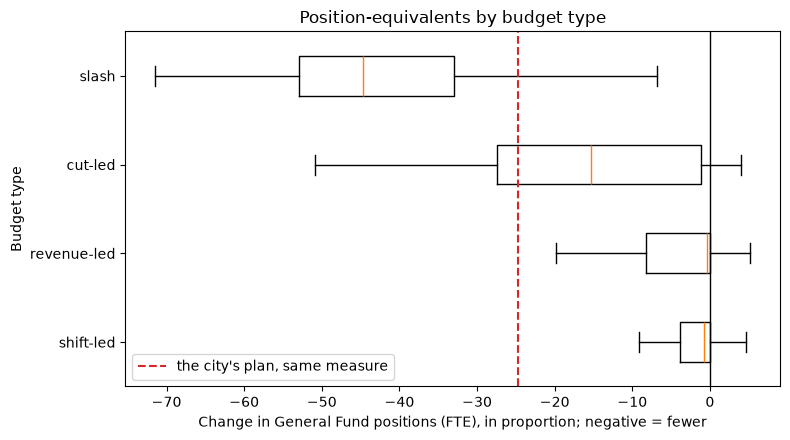

In [17]:
slash = responses_df['budget_type'].eq('slash')
dept_staff_df = pd.DataFrame({
    'gf_positions': pd.Series(GF_FTE),
    'slash_mean': pe_prop_df[slash].mean(),
    'all_mean': pe_prop_df.mean(),
    'city_plan': position_equivalents(city_pct_df).iloc[0],
}).rename(index=GF_LABEL)

present = [t for t in TYPE_ORDER if (responses_df['budget_type'] == t).any()][::-1]   # slash on top
f, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot([responses_df.loc[responses_df['budget_type'] == t, 'positions'] for t in present],
           orientation='horizontal', tick_labels=present, showfliers=False)
ax.axvline(city_positions, color='tab:red', ls='--', lw=1.5, label="the city's plan, same measure")
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Change in General Fund positions (FTE), in proportion; negative = fewer')
ax.set_ylabel('Budget type')
ax.set_title('Position-equivalents by budget type')
ax.legend(loc='lower left')
plt.tight_layout()
dept_staff_df.round(1)

## 4. Who closed it which way: cross-tabs against demographics (Q1, the hypothesis)

### A reusable cross-tab helper

The question throughout this section is whether budget choices differ by who the respondent is. The helper below builds a normalized cross-tab of a budget behavior against a demographic, drops the small 'Prefer not to say' and thin cells that can't support a comparison, and runs a chi-square test of independence as a rough flag for whether a difference is worth a sentence. The chi-square is a screening device, not a population inference — these are self-selected respondents, so a 'significant' result describes this pool, not Boulder.

In [18]:
def crosstab_behavior(df, demo_col, behavior_col, min_cell=10, drop=('Prefer not to say',)):
    """Normalized cross-tab + chi-square screen for one demographic vs. one behavior."""
    c0 = df[demo_col].notna() & ~df[demo_col].isin(drop)
    sub_df = df.loc[c0, [demo_col, behavior_col]].copy()
    # Keep only demographic groups with enough respondents to compare.
    keep = sub_df[demo_col].value_counts()
    keep = keep[keep >= min_cell].index
    sub_df = sub_df[sub_df[demo_col].isin(keep)]
    if sub_df[demo_col].nunique() < 2:
        return None, None, None
    counts = pd.crosstab(sub_df[demo_col], sub_df[behavior_col])
    shares = pd.crosstab(sub_df[demo_col], sub_df[behavior_col], normalize='index').round(3)
    chi2, p, dof, _ = stats.chi2_contingency(counts)
    return shares, counts, p


### Revenue vs. cuts, by housing tenure

The column's hypothesis says homeowners lean on cuts, so start with tenure: do renters and owners close the gap differently? The measure is `mostly_revenue`, whether at least half of a reader's fix came from new revenue. Tenure is also the variable where the respondent pool is most likely to diverge from Boulder, which makes it the natural bridge to the representativeness section.

In [19]:
shares_df, counts_df, p_val = crosstab_behavior(responses_df, 'demo_tenure', 'mostly_revenue')
print(f'Got at least half their fix from revenue, by tenure (chi-square p = {p_val:.3g}):')
shares_df

Got at least half their fix from revenue, by tenure (chi-square p = 2.4e-32):


mostly_revenue,False,True
demo_tenure,,
Other,0.731,0.269
Own,0.949,0.051
Rent,0.581,0.419


### The revenue share across the four demographics the column named (Q1)

Q1 names housing, tenure, age and income; "housing" is the survey's building-type question. For each, the table gives the number of readers, their mean revenue share and the share who got at least half their fix from revenue, by group. Groups with fewer than 10 readers are left out. A Kruskal–Wallis test on the revenue share plays the same screening role as the chi-square above.

In [20]:
Q1_DEMOS = ['demo_building', 'demo_tenure', 'demo_age', 'demo_income']
q1_frames, q1_p = [], {}
for d in Q1_DEMOS:
    c0 = responses_df[d].notna() & (responses_df[d] != 'Prefer not to say')
    g = responses_df[c0].groupby(d)
    t = pd.DataFrame({'n': g.size(), 'mean_rev_share': g['rev_share'].mean(),
                      'mostly_revenue': g['mostly_revenue'].mean()})
    t = t[t['n'] >= 10].reindex([o for o in OPTIONS[d] if o in t[t['n'] >= 10].index])
    groups = [grp['rev_share'].to_numpy() for name, grp in g if name in t.index]
    q1_p[d] = stats.kruskal(*groups).pvalue if len(groups) > 1 else np.nan
    t.index = pd.MultiIndex.from_product([[d], t.index], names=['demographic', 'group'])
    q1_frames.append(t)
q1_df = pd.concat(q1_frames)
print('Kruskal-Wallis p, revenue share across groups:', {k: round(float(v), 3) for k, v in q1_p.items()})
q1_df.round(3)

Kruskal-Wallis p, revenue share across groups: {'demo_building': 0.711, 'demo_tenure': 0.0, 'demo_age': 0.417, 'demo_income': 0.263}


n  \
demographic   group                                                     
demo_building Single-unit house detached from any other houses    125   
              Building with two or more homes (duplex, townho...  146   
              Manufactured home                                   155   
              Other                                               159   
demo_tenure   Own                                                 473   
              Rent                                                222   
              Other                                                26   
demo_age      18-24                                                40   
              25-34                                               149   
              35-44                                               172   
              45-54                                               152   
              55-64                                               125   
              65 and over                                         106   
demo_income   Less than $25,000 per year                           49   
              $25,000 to $49,999 per year                          89   
              $50,000 to $99,999 per year                         168   
              $100,000 to $149,999 per year                       162   
              $150,000 to $299,999 per year                       175   
              $300,000 per year or more                            99   

                                                                  mean_rev_share  \
demographic   group                                                                
demo_building Single-unit house detached from any other houses             0.232   
              Building with two or more homes (duplex, townho...           0.203   
              Manufactured home                                            0.223   
              Other                                                        0.241   
demo_tenure   Own                                                          0.099   
              Rent                                                         0.426   
              Other                                                        0.337   
demo_age      18-24                                                        0.234   
              25-34                                                        0.220   
              35-44                                                        0.250   
              45-54                                                        0.246   
              55-64                                                        0.187   
              65 and over                                                  0.202   
demo_income   Less than $25,000 per year                                   0.219   
              $25,000 to $49,999 per year                                  0.234   
              $50,000 to $99,999 per year                                  0.190   
              $100,000 to $149,999 per year                                0.205   
              $150,000 to $299,999 per year                                0.237   
              $300,000 per year or more                                    0.261   

                                                                  mostly_revenue  
demographic   group                                                               
demo_building Single-unit house detached from any other houses             0.192  
              Building with two or more homes (duplex, townho...           0.185  
              Manufactured home                                            0.200  
              Other                                                        0.208  
demo_tenure   Own                                                          0.051  
              Rent                                                         0.419  
              Other                                                        0.269  
demo_age      18-24   

### The hypothesis, part two: do those readers cut rather than raise revenue?

The column's hypothesis names three groups: homeowners, older residents and people with graduate degrees. Here "older" means 55 and over, and a graduate degree is a master's, professional or doctoral degree. For each group, compare its mean revenue share with that of everyone else who answered the question. The hypothesis predicts a lower share for each group, so `as_hypothesized` is true when the group's share is lower.

In [21]:
GRAD = ["Master's degree", 'Professional degree (MD, JD, DDS)', 'Doctoral degree (PhD, EdD)']
OLDER = ['55-64', '65 and over']
hyp_groups = {
    'homeowners vs. renters':   ('demo_tenure', ['Own'], ['Rent']),
    '55 and over vs. under 55': ('demo_age', OLDER, ['18-24', '25-34', '35-44', '45-54']),
    'graduate degree vs. none': ('demo_education', GRAD,
                                 [o for o in OPTIONS['demo_education'] if o not in GRAD + ['Prefer not to say']]),
}
hyp_rows = {}
for label, (col, yes, no) in hyp_groups.items():
    a = responses_df.loc[responses_df[col].isin(yes), 'rev_share']
    b = responses_df.loc[responses_df[col].isin(no), 'rev_share']
    hyp_rows[label] = {'n_group': len(a), 'n_rest': len(b),
                       'rev_share_group': a.mean(), 'rev_share_rest': b.mean(),
                       'difference_pp': (a.mean() - b.mean()) * 100,
                       'as_hypothesized': a.mean() < b.mean()}
hyp_df = pd.DataFrame(hyp_rows).T.infer_objects()
hyp_df.round(3)

,n_group,n_rest,rev_share_group,rev_share_rest,difference_pp,as_hypothesized
homeowners vs. renters,473,222,0.099,0.426,-32.700,True
55 and over vs. under 55,231,513,0.194,0.239,-4.510,True
graduate degree vs. none,409,341,0.228,0.219,0.891,False


### The same view as a chart

A grouped bar of the share of each group choosing each approach makes the pattern legible at a glance. This is a draft chart; the published version would be rebuilt in Datawrapper per the chart-discipline reference.

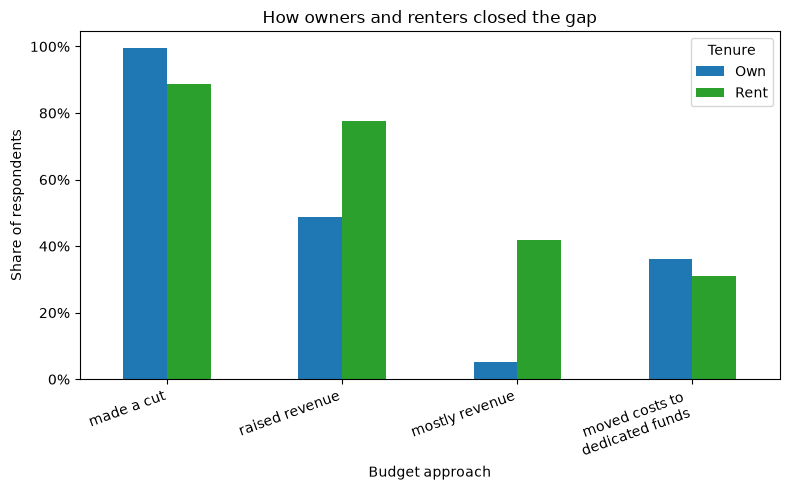

In [22]:
behaviors = ['any_cut', 'used_revenue', 'mostly_revenue', 'used_shift']
by_tenure_df = (responses_df[responses_df['demo_tenure'].isin(['Own', 'Rent'])]
                .groupby('demo_tenure')[behaviors].mean())

f, ax = plt.subplots(figsize=(8, 5))
by_tenure_df.T.plot.bar(ax=ax, color=['tab:blue', 'tab:green'], lw=3)
ax.set_ylabel('Share of respondents')
ax.set_xlabel('Budget approach')
ax.set_title('How owners and renters closed the gap')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xticklabels(['made a cut', 'raised revenue', 'mostly revenue', 'moved costs to\ndedicated funds'], rotation=20, ha='right')
ax.legend(title='Tenure')
plt.tight_layout()

### Scanning several demographics at once

Rather than eyeball every pairing, screen each demographic against each budget behavior with the chi-square helper and collect the p-values into one table. The first four rows are the demographics the column named in Q1; the rest are exploratory. Small values flag pairings worth a closer look (and possibly a sentence in the column); they do **not** establish anything about Boulder at large. Blank cells are pairings without enough respondents to test.

In [23]:
screen_demos = Q1_DEMOS + ['demo_education', 'demo_years', 'demo_gender']
screen_behaviors = ['any_cut', 'used_revenue', 'mostly_revenue', 'used_shift', 'maxed_out']

screen = pd.DataFrame(index=screen_demos, columns=screen_behaviors, dtype=float)
for d in screen_demos:
    for b in screen_behaviors:
        _, _, p = crosstab_behavior(responses_df, d, b)
        screen.loc[d, b] = p
screen.round(3)

,any_cut,used_revenue,mostly_revenue,used_shift,maxed_out
demo_building,0.180,0.287,0.965,0.367,0.060
demo_tenure,0.000,0.000,0.000,0.304,0.060
demo_age,0.962,0.230,0.586,0.213,0.125
demo_income,0.680,0.370,0.288,0.023,0.683
demo_education,0.533,0.325,0.659,0.832,0.677
demo_years,0.595,0.386,0.564,0.696,0.173
demo_gender,0.766,0.783,0.838,0.761,0.794


A note on reading this table: with seven demographics times five behaviors we are running 35 screens, so some small p-values will appear by chance alone. Treat the table as a place to *look*, confirm any candidate finding by inspecting the actual shares (as in the tenure example), and report effect sizes — how many points apart the groups are — rather than p-values in the column itself.

## 5. Readers versus the council's ballot and the staff recommendation (Q3, Q4)

### Consensus versus council (Q3)

First, which levers drew the most support. A lever's support is the share of readers who moved it each way from where it started: for a department, more or less spending than its status quo; for revenue, more or less money. `net_raise` is the share who raised it minus the share who cut it, so the most negative General Fund rows are the strongest consensus for cuts and the most positive revenue rows the strongest consensus for new money.

Then, the ballot. On Aug. 6 the council sent voters four city measures for Nov. 3: a \$400M recreation-and-safety bond for aging rec centers, fire stations and a police facility, repaid by a property tax of about \$400 a year on a \$1 million home; a charter change letting the city borrow against property's actual value; collective bargaining for firefighters; and a \$4,000-a-year tax on homes left empty more than half the year, starting in 2028. A parks mill levy the council studied did not make the ballot, and nothing on it raises the sales tax.

The tool has no slider for the bond, the charter change or the vacancy tax, so the comparison is directional: did readers move the closest levers the way the ballot does? The bond's property tax pays debt on buildings, not General Fund operations, so "raised the property tax" is the nearest reader measure, not the same thing. Measures with no reader counterpart are listed and left blank.

In [24]:
# Every General Fund and revenue lever, where it starts, and how readers moved it.
LEVERS = {**{f'gf_{k}': GF_LABEL[k] for k in GF_AMOUNT},
          'rev_fees': 'Fees & charges', 'rev_property': 'Property tax', 'rev_sales': 'Sales & use tax',
          'rev_marijuana': 'Recreational marijuana tax', 'rev_shift': 'Costs moved to dedicated funds'}
START = {c: 0 for c in LEVERS}
START['rev_marijuana'] = MJ_NOW
lever_df = pd.DataFrame({
    'lever': pd.Series(LEVERS),
    'kind': pd.Series({c: 'General Fund' if c.startswith('gf_') else 'revenue' for c in LEVERS}),
    'raised': pd.Series({c: (responses_df[c] > START[c]).mean() for c in LEVERS}),
    'cut': pd.Series({c: (responses_df[c] < START[c]).mean() for c in LEVERS}),
})
lever_df['left_alone'] = 1 - lever_df['raised'] - lever_df['cut']
lever_df['net_raise'] = lever_df['raised'] - lever_df['cut']
lever_df = lever_df.sort_values('net_raise')

q3_gf_top = lever_df.loc[lever_df['kind'] == 'General Fund', 'cut'].idxmax()
q3_rev_top = lever_df.loc[lever_df['kind'] == 'revenue', 'raised'].idxmax()
print(f"Most support among General Fund levers: cutting {LEVERS[q3_gf_top]} ({lever_df.loc[q3_gf_top, 'cut']:.1%} of readers)")
print(f"Most support among revenue levers: raising the {LEVERS[q3_rev_top].lower()} ({lever_df.loc[q3_rev_top, 'raised']:.1%})")
lever_df.round(3)

Most support among General Fund levers: cutting General Government (79.3% of readers)
Most support among revenue levers: raising the property tax (49.6%)


,lever,kind,raised,cut,left_alone,net_raise
gf_genadmin,General Government,General Fund,0.000,0.793,0.207,-0.793
gf_police,Police,General Fund,0.000,0.628,0.372,-0.628
rev_sales,Sales & use tax,revenue,0.144,0.327,0.529,-0.183
gf_parksrec,Parks & Recreation (GF share),General Fund,0.068,0.188,0.743,-0.120
gf_hhs,Housing & Human Services (GF share),General Fund,0.156,0.171,0.673,-0.016
gf_it,Innovation & Technology,General Fund,0.130,0.135,0.736,-0.005
gf_fire,Fire-Rescue,General Fund,0.000,0.000,1.000,0.000
gf_manager,City Manager's Office,General Fund,0.000,0.000,1.000,0.000
gf_finance,Finance,General Fund,0.000,0.000,1.000,0.000
gf_facilities,Facilities & Fleet (GF share),General Fund,0.000,0.000,1.000,0.000


In [25]:
_rd = responses_df
ballot_df = pd.DataFrame([
    ('$400M recreation-and-safety bond, repaid by a property tax', 'raised the property tax',
     (_rd['rev_property'] > 0).mean()),
    ('  the bond pays for rec centers, fire stations and a police facility',
     'left Parks & Recreation, Fire-Rescue and Police uncut',
     (_rd[['gf_parksrec', 'gf_fire', 'gf_police']] >= 0).all(axis=1).mean()),
    ('Collective bargaining for firefighters', 'kept or raised Fire-Rescue spending', (_rd['gf_fire'] >= 0).mean()),
    ('$4,000-a-year vacancy tax, from 2028', 'no slider: the tool locks it', np.nan),
    ('Charter change: borrow against actual property value', 'no slider', np.nan),
    ('Not on the ballot: a sales tax increase', 'raised the sales tax', (_rd['rev_sales'] > 0).mean()),
    ('Not on the ballot: a property tax cut', 'cut the property tax', (_rd['rev_property'] < 0).mean()),
], columns=['ballot_measure', 'closest_reader_measure', 'share_of_readers']).set_index('ballot_measure')
ballot_df.round(3)

,closest_reader_measure,share_of_readers
ballot_measure,,
"$400M recreation-and-safety bond, repaid by a property tax",raised the property tax,0.496
"the bond pays for rec centers, fire stations and a police facility","left Parks & Recreation, Fire-Rescue and Polic...",0.306
Collective bargaining for firefighters,kept or raised Fire-Rescue spending,1.000
"$4,000-a-year vacancy tax, from 2028",no slider: the tool locks it,NaN
Charter change: borrow against actual property value,no slider,NaN
Not on the ballot: a sales tax increase,raised the sales tax,0.144
Not on the ballot: a property tax cut,cut the property tax,0.103


### Disagreement with recommendations (Q4)

The budget city staff recommended is the city manager's recommended 2027 budget, and the tool marks it with the blue ticks: each department's recommended amount, the marijuana tax at 5.5% and \$566,128 of General Fund costs moved onto dedicated funds. For the fee, property-tax and sales-tax sliders, staff's position is where they start, the 2027 forecast with no tax change.

For each lever, a reader's **divergence** is the dollar difference between their setting and staff's, positive when they spend or raise more than staff. The levers are ranked by the mean absolute divergence, which counts a \$1M cut and a \$1M increase alike; the mean signed divergence says which way readers leaned, and `share_diverging` how many departed at all. The department sliders move in whole percents and the cost shift in \$0.1M steps, so a department within half a point of its tick, or a shift of \$0.6M, counts as matching staff.

Every slider starts at the status quo rather than at staff's position, so a reader who never touched a department, the marijuana tax or the cost shift diverges from staff by the city's own change; `left_at_start` reports how many left each lever where it started. Department divergences inherit the estimated starting points. The comparison is with the recommended budget, not the one the council adopts on Oct. 15.

In [26]:
# Staff's position on each lever: the blue ticks, and no change for fees and taxes.
STAFF = {f'gf_{k}': CITY_GF_PCT[k] for k in GF_AMOUNT}
STAFF.update({'rev_fees': 0, 'rev_property': 0, 'rev_sales': 0, 'rev_marijuana': CITY_MJ_RATE, 'rev_shift': CITY_SHIFT})
STAFF_LABEL = {f'gf_{k}': f'recommended ({CITY_GF_PCT[k]:+.1f}%)' for k in GF_AMOUNT}
STAFF_LABEL.update({'rev_fees': 'no change', 'rev_property': 'no change', 'rev_sales': 'no change',
                    'rev_marijuana': '5.5%', 'rev_shift': '$0.566M'})
# Matching staff: departments move in whole percents, the cost shift in $0.1M steps.
TOL = {c: (0.5 if c.startswith('gf_') else 0.05 if c == 'rev_shift' else 0) for c in LEVERS}

# Each reader's divergence from staff, $M (+ = more spending or more revenue than staff).
div_df = pd.DataFrame({**{f'gf_{k}': (responses_df[f'gf_{k}'] - STAFF[f'gf_{k}']) / 100 * amt for k, amt in GF_AMOUNT.items()},
                       **{f'rev_{k}': responses_df[f'rev_{k}'] / 100 * base for k, base in REV_BASE.items()}})
div_df['rev_marijuana'] = marijuana_yield(responses_df['rev_marijuana']) - float(marijuana_yield(CITY_MJ_RATE))
div_df['rev_shift'] = responses_df['rev_shift'] - CITY_SHIFT

diverging = {c: (responses_df[c] - STAFF[c]).abs() > TOL[c] for c in LEVERS}
q4_div = pd.DataFrame({
    'lever': pd.Series(LEVERS),
    'staff': pd.Series(STAFF_LABEL),
    'share_diverging': pd.Series({c: d.mean() for c, d in diverging.items()}),
    'mean_signed_$M': div_df.mean(),
    'mean_abs_$M': div_df.abs().mean(),
    'left_at_start': pd.Series({c: (responses_df[c] == START[c]).mean() for c in LEVERS}),
}).sort_values('mean_abs_$M', ascending=False)

total_div_s = div_df.abs().sum(axis=1)
print('Greatest divergence from staff (mean absolute, $M):')
for c, r in q4_div.head(3).iterrows():
    print(f"  {r['lever']:<34} ${r['mean_abs_$M']:.2f}M  (leaning {'up' if r['mean_signed_$M'] > 0 else 'down'}, "
          f"{r['share_diverging']:.0%} of readers diverged)")
print(f'Median reader: ${total_div_s.median():.2f}M of total divergence across all levers')
q4_div.round(3)

Greatest divergence from staff (mean absolute, $M):
  Sales & use tax                    $3.93M  (leaning down, 47% of readers diverged)
  Police                             $3.66M  (leaning down, 100% of readers diverged)
  General Government                 $2.99M  (leaning down, 97% of readers diverged)
Median reader: $16.90M of total divergence across all levers


,lever,staff,share_diverging,mean_signed_$M,mean_abs_$M,left_at_start
rev_sales,Sales & use tax,no change,0.471,-2.074,3.933,0.529
gf_police,Police,recommended (-0.6%),0.997,-3.416,3.660,0.372
gf_genadmin,General Government,recommended (-2.4%),0.973,-2.617,2.994,0.207
rev_property,Property tax,no change,0.599,2.596,2.904,0.401
gf_other,Other General Fund departments,recommended (-7.7%),1.000,1.391,1.391,1.000
rev_shift,Costs moved to dedicated funds,$0.566M,0.987,0.345,1.103,0.651
gf_it,Innovation & Technology,recommended (-8.3%),1.000,0.972,0.972,0.736
gf_fire,Fire-Rescue,recommended (-2.7%),1.000,0.860,0.860,1.000
rev_fees,Fees & charges,no change,0.521,0.352,0.533,0.479
gf_hhs,Housing & Human Services (GF share),recommended (+2.3%),0.974,-0.319,0.418,0.673


Department by department, the same comparison in percentage points: how many readers matched staff's number (within half a point of the tick), cut below it or kept more, and how many took a department below its restated 2026 budget. Then the revenue levers, measured against staff's moves.

In [27]:
city_df = pd.DataFrame({'label': pd.Series(GF_LABEL), 'staff_tick_pct': pd.Series(CITY_GF_PCT)})
for k in GF_AMOUNT:
    s, tick = responses_df[f'gf_{k}'], CITY_GF_PCT[k]
    amount = GF_AMOUNT[k] * (1 + s / 100)                         # each reader's 2027 amount, $M
    city_df.loc[k, 'matched_staff'] = ((s - tick).abs() <= 0.5).mean()
    city_df.loc[k, 'cut_below_staff'] = (s < tick - 0.5).mean()
    city_df.loc[k, 'kept_above_staff'] = (s > tick + 0.5).mean()
    city_df.loc[k, 'below_2026'] = (amount < GF_2026[k]).mean()
    city_df.loc[k, 'mean_change_from_2026'] = ((amount / GF_2026[k] - 1) * 100).mean()
city_df = city_df.sort_values('cut_below_staff', ascending=False)
city_df.round(3)

,label,staff_tick_pct,matched_staff,cut_below_staff,kept_above_staff,below_2026,mean_change_from_2026
hhs,Housing & Human Services (GF share),2.277,0.026,0.873,0.101,0.037,6.373
genadmin,General Government,-2.371,0.027,0.757,0.216,1.000,-13.505
police,Police,-0.603,0.003,0.626,0.372,0.391,1.248
parksrec,Parks & Recreation (GF share),-4.359,0.025,0.099,0.876,0.048,6.652
fire,Fire-Rescue,-2.687,0.000,0.000,1.000,0.000,9.884
it,Innovation & Technology,-8.342,0.000,0.000,1.000,0.000,12.341
manager,City Manager's Office,-1.504,0.000,0.000,1.000,0.000,9.714
facilities,Facilities & Fleet (GF share),-5.286,0.000,0.000,1.000,0.000,3.942
finance,Finance,-4.578,0.000,0.000,1.000,0.000,6.976
attorney,City Attorney's Office,0.073,1.000,0.000,0.000,0.000,8.822


In [28]:
mj, sh = responses_df['rev_marijuana'], responses_df['rev_shift']
rev_city = pd.DataFrame({
    'city_move': ['to 5.5% from 3.5%', '$0.566M', 'no change (its fee changes are in the forecast)', 'no change', 'no change'],
    'with_city': [(mj >= CITY_MJ_RATE).mean(), (sh >= CITY_SHIFT - 0.05).mean(), (responses_df['rev_fees'] == 0).mean(),
                  (responses_df['rev_property'] == 0).mean(), (responses_df['rev_sales'] == 0).mean()],
    'raised': [(mj > MJ_NOW).mean(), (sh > 0).mean(), (responses_df['rev_fees'] > 0).mean(),
               (responses_df['rev_property'] > 0).mean(), (responses_df['rev_sales'] > 0).mean()],
    'cut': [(mj < MJ_NOW).mean(), 0.0, (responses_df['rev_fees'] < 0).mean(),
            (responses_df['rev_property'] < 0).mean(), (responses_df['rev_sales'] < 0).mean()],
}, index=['marijuana tax', 'costs moved to dedicated funds', 'fees & charges', 'property tax', 'sales tax'])

top_dept = city_df['cut_below_staff'].idxmax()
majority_cuts = city_df.index[city_df['cut_below_staff'] > 0.5].map(GF_LABEL).tolist()
print(f"Cut furthest below staff: {GF_LABEL[top_dept]} ({city_df.loc[top_dept, 'cut_below_staff']:.1%} of readers)")
print('Departments a majority cut below staff:', majority_cuts or 'none')
rev_city.round(3)

Cut furthest below staff: Housing & Human Services (GF share) (87.3% of readers)
Departments a majority cut below staff: ['Housing & Human Services (GF share)', 'General Government', 'Police']


,city_move,with_city,raised,cut
marijuana tax,to 5.5% from 3.5%,0.268,0.408,0.043
costs moved to dedicated funds,$0.566M,0.317,0.349,0.000
fees & charges,no change (its fee changes are in the forecast),0.479,0.359,0.162
property tax,no change,0.401,0.496,0.103
sales tax,no change,0.529,0.144,0.327


### Exploratory: the city's own outreach, Fund Our Future

This comparison is exploratory; it is not one of the column's questions. In spring 2026 the city ran its own trade-off exercise, **Fund Our Future**. Eight community conversations ran from March 31 through April 19 (63 surveys), and an online link drew 536 more, for 599 submissions; the 509 that spent exactly 100 dots are the ones the city scored. Each respondent spread 100 dots across 25 city services: 4 dots means keep a service as it is, more means increase it, fewer means reduce it. The city's report calls both channels "self-selected engagement exercises, not statistically valid polls," which is also true of this pool, so treat agreement or disagreement as a comparison of two engaged publics, not of either one with Boulder.

The top of the city's list: ongoing maintenance of facilities (a mean of 6.23 dots), wildfire response (6.23), wildfire preparedness and mitigation (6.03), encampment abatement through SAMPS (5.78) and pavement management (5.62). The bottom: business incentives (2.89), rental assistance (2.77) and re-housing (2.72).

To compare, each service is matched to the General Fund slider that pays for it. The match is fixed here, before real responses, and it is coarse: several services are paid for outside the General Fund (pavement and snow removal, open space, recreation programs, affordable housing, arts grants, building permits and climate programs), and SAMPS draws on several departments, so those are left out. A department **agrees** with Fund Our Future when readers cut it on average and the city's respondents gave its services fewer than 4 dots, or readers kept or raised it on average (an average change of zero or more) and the city's respondents gave its services more than 4.

Source: the city's report, [Fund Our Future: Spring 2026 Community Engagement Results](https://bouldercolorado.gov/media/21028/download?inline) (Long-Term Financial Strategy), Table 3, and its [June 29, 2026 summary](https://bouldercolorado.gov/news/fund-our-future-our-communitys-priorities).

In [29]:
# Fund Our Future, Table 3: mean dots per service across the 509 complete surveys
# (4 = keep as is), and the General Fund slider each maps to. None marks a service
# paid for outside the General Fund or across several departments; those are left out.
FOF_SERVICES = [
    ('Ongoing Maintenance of Facilities',       6.23, 'facilities'),
    ('Wildfire Response',                       6.23, 'fire'),
    ('Wildfire Preparedness and Mitigation',    6.03, 'fire'),
    ('SAMPS (Encampment Abatement)',            5.78, None),   # several departments
    ('Pavement Management Services',            5.62, None),   # transportation funds
    ('Police Patrol Emergency Response',        5.30, 'police'),
    ('Snow and Ice Response',                   5.21, None),   # transportation funds
    ('Paramedic Emergency Response',            4.64, 'fire'),
    ('Land Management Science and Research',    3.80, None),   # open space funds
    ('Education, Outreach (Open Space)',        3.77, None),   # open space funds
    ('Youth and Older Adult Indoor Recreation', 3.74, None),   # recreation funds
    ('Age Well Centers',                        3.53, None),   # unclear which fund pays
    ('Indoor Aquatic Programming',              3.43, None),   # recreation funds
    ('Affordable Housing Investments',          3.39, None),   # housing funds
    ('Older Adult (60+) Case Management',       3.34, 'hhs'),
    ('Youth Services Initiatives (YSI)',        3.21, 'hhs'),
    ('Arts and Cultural Grants',                3.17, None),   # the arts tax
    ('Circular Economy and Zero Waste',         3.14, None),   # the climate tax
    ('Sheltering and Day Services',             3.14, 'hhs'),
    ('Building Permit Review',                  3.09, None),   # development fees
    ('Energy Community Programs',               2.92, None),   # the climate tax
    ('Family Resource Schools',                 2.90, 'hhs'),
    ('Business Incentives',                     2.89, 'manager'),
    ('Rental Assistance',                       2.77, 'hhs'),
    ('Re-Housing',                              2.72, 'hhs'),
]
fof_df = pd.DataFrame(FOF_SERVICES, columns=['service', 'fof_mean', 'slider'])
mapped_df = fof_df.dropna(subset=['slider'])
q4_df = mapped_df.groupby('slider').agg(services=('service', 'count'), fof_mean=('fof_mean', 'mean'))
q4_df['label'] = q4_df.index.map(GF_LABEL)
q4_df['fof_vote'] = np.where(q4_df['fof_mean'] > 4, 'increase', 'reduce')
q4_df['pool_mean_pct'] = [responses_df[f'gf_{k}'].mean() for k in q4_df.index]
q4_df['pool_share_cut'] = [(responses_df[f'gf_{k}'] < 0).mean() for k in q4_df.index]
q4_df['pool_vote'] = np.where(q4_df['pool_mean_pct'] < 0, 'reduce', 'keep or increase')
q4_df['agrees'] = (q4_df['fof_vote'] == 'increase') == (q4_df['pool_vote'] == 'keep or increase')
q4_df = q4_df.sort_values('fof_mean', ascending=False)
rho = stats.spearmanr(q4_df['fof_mean'], q4_df['pool_mean_pct'])[0]
print(f'{len(mapped_df)} of {len(fof_df)} Fund Our Future services map to a General Fund slider.')
print(f'Departments where the pool agrees with Fund Our Future: {int(q4_df["agrees"].sum())} of {len(q4_df)}; '
      f'rank correlation {rho:.2f} across {len(q4_df)} departments (descriptive only).')
q4_df[['label', 'services', 'fof_mean', 'fof_vote', 'pool_mean_pct', 'pool_share_cut', 'pool_vote', 'agrees']].round(3)

12 of 25 Fund Our Future services map to a General Fund slider.
Departments where the pool agrees with Fund Our Future: 3 of 5; rank correlation 0.22 across 5 departments (descriptive only).


,label,services,fof_mean,fof_vote,pool_mean_pct,pool_share_cut,pool_vote,agrees
slider,,,,,,,,
facilities,Facilities & Fleet (GF share),1,6.230,increase,0.000,0.000,keep or increase,True
fire,Fire-Rescue,3,5.633,increase,0.000,0.000,keep or increase,True
police,Police,1,5.300,increase,-6.861,0.628,reduce,False
hhs,Housing & Human Services (GF share),6,3.013,reduce,-0.035,0.171,reduce,True
manager,City Manager's Office,1,2.890,reduce,0.000,0.000,keep or increase,False


## 6. How representative is the pool? Benchmarks from BVCP and the Census (the hypothesis)

### Two benchmarks, two questions

'Representative of what?' has two answers, and we keep both:

- The **2025 BVCP survey** is the city's own *statistically valid* instrument — a probability-based read of Boulder Valley residents. Comparing to it answers: *does our self-selected pool look like the city's valid survey?*
- The **Census ACS** (2019–2023 5-year estimates for the city of Boulder) is the population benchmark. Comparing to it answers: *does our pool look like Boulder's adult population?*

> **Both benchmark tables below are placeholders pending the exact published figures.** The ACS values are drawn from the 2019–2023 ACS 5-year estimates for the city of Boulder and should be replaced with exact pulls from the relevant ACS tables (tenure **B25003**, age **B01001**, educational attainment **B15003**, household income **B19001**) via the [Census API](https://www.census.gov/data/developers/data-sets/acs-5year.html) or [data.census.gov](https://data.census.gov/). The BVCP column should be filled from the city's published [BVCP survey](https://bouldervalleycompplan.net/) topline. Until then, treat the *gaps* as illustrative of the method, not as final numbers.

In [30]:
# --- Benchmark marginals (shares within each variable) -----------------------
# PLACEHOLDER VALUES. Replace BVCP with the city's published survey topline and ACS
# with exact table pulls (see the markdown note above). ACS figures here approximate
# the 2019-2023 ACS 5-year estimates for the city of Boulder.

# Tenure: ACS B25003 for the city of Boulder is ~48% owner / 52% renter.
benchmarks = {
    'demo_tenure': pd.DataFrame({
        'pool':  np.nan,  # filled from the data below
        'bvcp':  {'Own': 0.52, 'Rent': 0.48},                 # PLACEHOLDER
        'acs':   {'Own': 0.48, 'Rent': 0.52},                 # ~ACS B25003, city of Boulder
    }),
    'demo_age': pd.DataFrame({
        'pool':  np.nan,
        'bvcp':  {'18-24': 0.15, '25-34': 0.20, '35-44': 0.16,
                  '45-54': 0.14, '55-64': 0.15, '65 and over': 0.20},   # PLACEHOLDER
        'acs':   {'18-24': 0.27, '25-34': 0.19, '35-44': 0.13,
                  '45-54': 0.11, '55-64': 0.12, '65 and over': 0.18},   # ~ACS B01001 (18+), city
    }),
    'demo_education': pd.DataFrame({
        'pool':  np.nan,
        'bvcp':  {'High school diploma': 0.05, 'Some college, no degree': 0.10,
                  'Associate degree': 0.04, "Bachelor's degree": 0.34,
                  "Master's degree": 0.28, 'Doctoral degree (PhD, EdD)': 0.12,
                  'Professional degree (MD, JD, DDS)': 0.07},            # PLACEHOLDER
        'acs':   {'High school diploma': 0.09, 'Some college, no degree': 0.12,
                  'Associate degree': 0.03, "Bachelor's degree": 0.40,
                  "Master's degree": 0.24, 'Doctoral degree (PhD, EdD)': 0.06,
                  'Professional degree (MD, JD, DDS)': 0.06},            # ~ACS B15003 (25+), city
    }),
    'demo_income': pd.DataFrame({
        'pool':  np.nan,
        'bvcp':  {'Less than $25,000 per year': 0.12, '$25,000 to $49,999 per year': 0.13,
                  '$50,000 to $99,999 per year': 0.22, '$100,000 to $149,999 per year': 0.20,
                  '$150,000 to $299,999 per year': 0.23, '$300,000 per year or more': 0.10},  # PLACEHOLDER
        'acs':   {'Less than $25,000 per year': 0.18, '$25,000 to $49,999 per year': 0.15,
                  '$50,000 to $99,999 per year': 0.22, '$100,000 to $149,999 per year': 0.17,
                  '$150,000 to $299,999 per year': 0.19, '$300,000 per year or more': 0.09},  # ~ACS B19001, city
    }),
}
list(benchmarks)

['demo_tenure', 'demo_age', 'demo_education', 'demo_income']

### Pool vs. benchmarks, side by side

For each benchmarked variable, compute the pool's own distribution (excluding 'Prefer not to say' so the shares are comparable to the benchmarks) and place it next to the BVCP and ACS columns. The `gap_vs_acs` column is the percentage-point difference between the pool and the population — the thing reweighting will try to close.

In [31]:
def pool_distribution(df, col, categories):
    """Share of each category among respondents who gave a real answer."""
    c0 = df[col].notna() & (df[col] != 'Prefer not to say')
    counts = df.loc[c0, col].value_counts()
    return (counts.reindex(categories).fillna(0) / counts.sum())

rep_tables = {}
for col, bench_df in benchmarks.items():
    cats = [c for c in bench_df.index]
    out = bench_df.copy()
    out['pool'] = pool_distribution(responses_df, col, cats)
    out['gap_vs_acs'] = (out['pool'] - out['acs'])
    out['gap_vs_bvcp'] = (out['pool'] - out['bvcp'])
    rep_tables[col] = out.round(3)

rep_tables['demo_tenure']


,pool,bvcp,acs,gap_vs_acs,gap_vs_bvcp
Own,0.656,0.52,0.48,0.176,0.136
Rent,0.308,0.48,0.52,-0.212,-0.172


### The hypothesis, part one: does the pool skew as predicted?

The column predicted more homeowners, older residents and graduate degrees than Boulder has. Using the same benchmark tables, which are placeholders until the exact ACS pulls and the BVCP topline are in, compare the pool's share of each group with the benchmarks. `as_hypothesized` is true when the pool's share is above the ACS share.

In [32]:
def group_share(df, col, cats):
    """Share of readers in `cats` among those who answered `col`."""
    c0 = df[col].notna() & (df[col] != 'Prefer not to say')
    return df.loc[c0, col].isin(cats).mean()

skew_groups = {'homeowners': ('demo_tenure', ['Own']), '55 and over': ('demo_age', OLDER),
               'graduate degree': ('demo_education', GRAD)}
skew_df = pd.DataFrame({label: {'pool': group_share(responses_df, col, cats),
                                'acs': benchmarks[col]['acs'].reindex(cats).sum(),
                                'bvcp': benchmarks[col]['bvcp'].reindex(cats).sum()}
                        for label, (col, cats) in skew_groups.items()}).T
skew_df['gap_vs_acs_pp'] = (skew_df['pool'] - skew_df['acs']) * 100
skew_df['as_hypothesized'] = skew_df['pool'] > skew_df['acs']
skew_df.round(3)

,pool,acs,bvcp,gap_vs_acs_pp,as_hypothesized
homeowners,0.656,0.48,0.52,17.603,True
55 and over,0.310,0.30,0.35,1.048,True
graduate degree,0.545,0.36,0.47,18.533,True


### A representativeness chart for one variable

Tenure is the sharpest illustration: a self-selected civic-engagement pool typically over-represents homeowners, who have more at stake in municipal budgets and more time to spend on a budget puzzle. The chart shows the three distributions side by side.

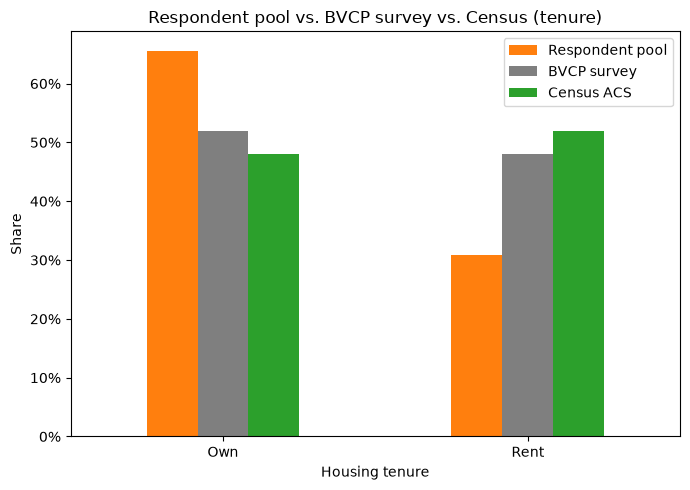

In [33]:
ten_df = rep_tables['demo_tenure'][['pool', 'bvcp', 'acs']]

f, ax = plt.subplots(figsize=(7, 5))
ten_df.plot.bar(ax=ax, color=['tab:orange', 'tab:gray', 'tab:green'], lw=3)
ax.set_ylabel('Share')
ax.set_xlabel('Housing tenure')
ax.set_title('Respondent pool vs. BVCP survey vs. Census (tenure)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(['Respondent pool', 'BVCP survey', 'Census ACS'])
ax.set_xticklabels(ten_df.index, rotation=0)
plt.tight_layout()


## 7. Reweighting: estimating the BRL-pool-vs-Boulder gap

### What reweighting does, and what it can't

If the pool has too many homeowners, one fix is to count each homeowner's response a little less and each renter's a little more, so the *weighted* pool matches Boulder's tenure split. That is **post-stratification**. Extending it to match several variables at once — tenure *and* age *and* income — is **raking**, or iterative proportional fitting (IPF): cycle through the variables, rescaling weights to match one margin at a time, and repeat until the weights stop moving.

Two cautions frame everything in this section:

1. **Reweighting corrects observed skew only.** It makes the pool's *measured* demographics match the target. It does nothing about the unmeasured ways budget-puzzle-takers differ from non-takers (civic interest, free time, strong priors about city spending). A perfectly reweighted self-selected sample is still a self-selected sample.
2. **Weights cost precision.** Up-weighting a small group inflates the variance of any estimate; the *effective sample size* can be far below the row count. We quantify that cost so it isn't hidden.

### Step 1 — post-stratification on a single variable (tenure)

Start with the simplest case to make the mechanic visible. The weight for each respondent is the target share of their group divided by the pool's share of that group. Renters (under-represented) get weights above 1; owners (over-represented) get weights below 1. We weight toward the ACS population benchmark here.

In [34]:
def post_stratify(df, col, target, drop=('Prefer not to say',)):
    """Single-variable post-stratification weights toward `target` (a share dict)."""
    c0 = df[col].notna() & ~df[col].isin(drop)
    pool_share = df.loc[c0, col].value_counts(normalize=True)
    w = pd.Series(1.0, index=df.index)
    for cat, tgt in target.items():
        if cat in pool_share.index and pool_share[cat] > 0:
            w.loc[df[col] == cat] = tgt / pool_share[cat]
    w.loc[~c0] = np.nan      # rows that skipped this item can't be post-stratified on it
    return w

tenure_target = benchmarks['demo_tenure']['acs'].to_dict()
w_tenure_s = post_stratify(responses_df, 'demo_tenure', tenure_target)
print('Tenure post-stratification weights (toward ACS):')
print(w_tenure_s.groupby(responses_df['demo_tenure']).mean().round(3).dropna())


Tenure post-stratification weights (toward ACS):
demo_tenure
Other    1.000
Own      0.732
Rent     1.689
dtype: float64


### What the single weight changes

Recompute one top-line figure — the mean revenue share, the column's cut vs. tax split — unweighted and then weighted toward the ACS tenure split. The movement is the tenure-skew correction, in isolation.

In [35]:
def weighted_mean(values_s, weights_s):
    c0 = values_s.notna() & weights_s.notna()
    v, w = values_s[c0].astype(float), weights_s[c0]
    return np.average(v, weights=w)

raw_share = responses_df['rev_share'].mean()
adj_share = weighted_mean(responses_df['rev_share'], w_tenure_s)
print(f'Mean revenue share | unweighted: {raw_share:.1%}   tenure-weighted (ACS): {adj_share:.1%}')

Mean revenue share | unweighted: 22.5%   tenure-weighted (ACS): 27.1%


### Step 2 — raking on several variables at once

Real reweighting matches more than one margin. The raking routine below cycles through tenure, age, income, and education, each iteration rescaling the running weight so the weighted pool matches that variable's target, then repeats until the weights converge. Respondents who skipped one of the raking variables keep a neutral factor for that variable (a simple, transparent choice; a production analysis might instead restrict to complete cases or impute). Weights are trimmed at the end to keep any single respondent from dominating.

In [36]:
def rake(df, targets, drop=('Prefer not to say',), max_iter=50, tol=1e-6, trim=(0.2, 5.0)):
    """Iterative proportional fitting toward several marginal `targets`.

    targets: dict of {column: {category: target_share}}.
    Returns a weight Series (mean 1.0) over all rows.
    """
    w = pd.Series(1.0, index=df.index)
    for _ in range(max_iter):
        w_before = w.copy()
        for col, target in targets.items():
            c0 = df[col].notna() & ~df[col].isin(drop)
            # Weighted share currently in each category.
            cur = w[c0].groupby(df.loc[c0, col]).sum()
            cur = cur / cur.sum()
            for cat, tgt in target.items():
                if cat in cur.index and cur[cat] > 0:
                    factor = tgt / cur[cat]
                    w.loc[(df[col] == cat) & c0] *= factor
        # Renormalize to mean 1 and check convergence.
        w *= len(w) / w.sum()
        if (w - w_before).abs().max() < tol:
            break
    # Trim extreme weights, then renormalize once more.
    lo, hi = np.quantile(w, trim[0] / 10), trim[1]
    w = w.clip(lower=max(lo, 0.2), upper=hi)
    w *= len(w) / w.sum()
    return w

rake_targets = {
    'demo_tenure': benchmarks['demo_tenure']['acs'].to_dict(),
    'demo_age': benchmarks['demo_age']['acs'].to_dict(),
    'demo_income': benchmarks['demo_income']['acs'].to_dict(),
    'demo_education': benchmarks['demo_education']['acs'].to_dict(),
}
w_rake_s = rake(responses_df, rake_targets)
print(f'Raked weights: mean={w_rake_s.mean():.3f}, min={w_rake_s.min():.3f}, max={w_rake_s.max():.3f}')


Raked weights: mean=1.000, min=0.222, max=5.559


### Did raking actually hit the targets?

A raking routine is only trustworthy if the weighted margins match the targets it was given. Check tenure as a spot audit: the weighted pool share should now sit on top of the ACS target.

In [37]:
c0 = responses_df['demo_tenure'].notna() & (responses_df['demo_tenure'] != 'Prefer not to say')
weighted_tenure_s = (w_rake_s[c0].groupby(responses_df.loc[c0, 'demo_tenure']).sum())
weighted_tenure_s = (weighted_tenure_s / weighted_tenure_s.sum()).round(3)
check_df = pd.DataFrame({'weighted_pool': weighted_tenure_s,
                         'acs_target': pd.Series(rake_targets['demo_tenure'])}).round(3)
check_df


,weighted_pool,acs_target
Other,0.013,NaN
Own,0.515,0.48
Rent,0.472,0.52


### The cost of weighting: effective sample size

Kish's effective sample size, n_eff = (Σw)² / Σ(w²), measures how many equal-weight responses the weighted pool is 'worth.' The design effect is n / n_eff. A large gap between the row count and n_eff is the precision the reweighting spent to buy representativeness — and a reason to report weighted figures as ranges, not points.

In [38]:
def effective_n(weights_s):
    w = weights_s.dropna()
    return (w.sum() ** 2) / (w ** 2).sum()

n_eff = effective_n(w_rake_s)
design_effect = len(w_rake_s) / n_eff
print(f'Nominal n:            {len(w_rake_s):,}')
print(f'Effective n (Kish):   {n_eff:,.0f}')
print(f'Design effect:        {design_effect:.2f}x')
print(f'Precision retained:   {n_eff / len(w_rake_s):.1%}')


Nominal n:            764
Effective n (Kish):   385
Design effect:        1.98x
Precision retained:   50.4%


### Top-line patterns, unweighted vs. raked

Finally, recompute the section-3 top-line behaviors under the raked weights and place them next to the unweighted figures. The `shift_pp` column is the estimated effect of the pool's observed demographic skew on each headline number. Read it as: *if the pool matched Boulder's tenure, age, income, and education, this is roughly how the figure would move* — and remember it still says nothing about the unobserved selection into the pool.

In [39]:
compare = {}
for b in ['any_cut', 'used_revenue', 'mostly_revenue', 'used_shift', 'maxed_out', 'rev_share']:
    compare[b] = {
        'unweighted': responses_df[b].mean(),
        'raked': weighted_mean(responses_df[b], w_rake_s),
    }
compare_df = pd.DataFrame(compare).T
compare_df['shift_pp'] = ((compare_df['raked'] - compare_df['unweighted']) * 100).round(1)
compare_df[['unweighted', 'raked']] = (compare_df[['unweighted', 'raked']] * 100).round(1)
compare_df.rename(columns={'unweighted': 'unweighted_%', 'raked': 'raked_%'})

,unweighted_%,raked_%,shift_pp
any_cut,95.8,95.3,-0.5
used_revenue,60.1,62.2,2.1
mostly_revenue,19.4,21.7,2.3
used_shift,34.9,35.8,0.9
maxed_out,27.7,32.2,4.4
rev_share,22.5,25.1,2.7


## 8. Limits and headline numbers

### What this analysis can and cannot support

- **The pool is self-selected.** Everyone here chose to open a budget interactive and finish it. No weighting fixes that. Treat every figure as describing *participants*, not Boulder.
- **Repeat budgets are set aside, as far as the widget can tell.** `repeat_client` flags a second budget from the same browser. A reader who clears the browser's storage or switches devices is not flagged, so treat the count as a floor.
- **The ballot comparison is directional.** The bond's property tax pays debt on buildings, not General Fund operations, and the vacancy tax and charter change have no slider, so Q3 compares the way readers moved the closest levers with what the council put to voters.
- **"Staff" means the recommended budget.** Q4 measures divergence from the city manager's recommended budget, not from the budget the council adopts on Oct. 15. Every slider starts at the status quo rather than at staff's position, so a reader who left a lever alone counts as diverging by the city's own change; the table reports how many did.
- **The department starting points are estimates.** The city publishes each department's recommended amount but not its status quo. The starting points undo the city's itemized 2027 changes and spread the part of the gap the city doesn't itemize by department, about \$6.3M, in proportion to department size (`embed/PROVENANCE.md`). Department-level comparisons with staff, and the department rows of Q4, inherit that estimate.
- **Fund Our Future is exploratory, and its match is coarse.** Twelve of its 25 services map to a General Fund slider; the rest are paid for outside the General Fund or across departments. Fund Our Future is self-selected too.
- **Reweighting is illustrative.** The raked numbers show what the pool's *observed* demographic skew is worth, against benchmark margins that are themselves placeholders until the BVCP topline and exact ACS pulls are dropped in. They are not population estimates and should not be reported with a margin of error.
- **Position-equivalents are a scale, not a layoff count.** They convert each budget's department dollars into General Fund positions at the department's average cost, in proportion to its personnel share or, as an upper bound, entirely from staff. A department could cut vacancies, overtime, contracts or programs instead; positions paid partly from other funds count only for their General Fund share; and the starting points are estimates. The measure also reads the part of the gap the city doesn't itemize, which the starting points spread across departments, as positions: that is why the city's plan scores about 25 fewer positions here while its staffing table shows a net gain of 2.40. Compare budgets with each other and with the city's plan measured the same way, not with the city's staffing table.
- **Planned versus exploratory.** The hypothesis and Q1–Q4, with the measures fixed in this notebook, are what the column committed to in advance. Everything else, including most of the chi-square screen and the budget types, clusters and position-equivalents, is exploratory, and the multiple-comparisons caveat in section 4 applies. None of the tests speaks for Boulder at large.
- **In `STUB_MODE` the inputs are synthetic.** Every number in a stub run is a property of the seeded generator, not of any real reader. Re-run with `STUB_MODE = False` on the Supabase export (`pipeline/export-responses.py`) before quoting anything.

The column built on this notebook should lead with the *descriptive* finding (how this engaged slice of Boulder closed the gap and where it disagreed with itself), use the representativeness gap as the honest caveat rather than burying it, and let the reweighting stand as a demonstration of method — what it would take to speak for Boulder, and why a budget puzzle can't.

### Pinned headline numbers

Every figure the column might quote, computed from named variables in one place so a critic can trace each back to its definition, in the order the column asked its questions.

In [40]:
print('PINNED HEADLINE NUMBERS  (STUB_MODE =', STUB_MODE, ')')
print('-' * 72)
print(f'Responses analyzed:                  {n_responses:,}  ({n_repeats:,} repeat budgets set aside)')
print(f'Median survey items answered:        {median_answers} of {len(DEMO_COLS)}')
print('Hypothesis, the skew (pool vs. ACS; benchmarks are placeholders):')
for label, r in skew_df.iterrows():
    print(f'  {label:<34} {r["pool"]:.1%} vs. {r["acs"]:.1%}')
print('Hypothesis, cuts over revenue (mean revenue share, group vs. rest):')
for label, r in hyp_df.iterrows():
    print(f'  {label:<34} {r["rev_share_group"]:.1%} vs. {r["rev_share_rest"]:.1%}')
print('Q1, the cut vs. tax split:')
print(f'  Mean revenue share of the fix:     {responses_df["rev_share"].mean():.1%}')
print(f'  Got at least half from revenue:    {responses_df["mostly_revenue"].mean():.1%}')
print(f'  Made at least one cut:             {responses_df["any_cut"].mean():.1%}')
print(f'  Moved costs onto dedicated funds:  {responses_df["used_shift"].mean():.1%}')
print('Q2, drastic or incremental:')
print(f'  Drastic (maxed out a slider):      {(responses_df["reform_style"] == "drastic").mean():.1%}')
print(f'  Incremental:                       {(responses_df["reform_style"] == "incremental").mean():.1%}')
print(f'  Median surplus past the gap:       ${responses_df["surplus"].median():.2f}M')
print('Q3, consensus versus council:')
print(f'  Most-supported General Fund lever: cutting {LEVERS[q3_gf_top]} ({lever_df.loc[q3_gf_top, "cut"]:.1%})')
print(f'  Most-supported revenue lever:      raising the {LEVERS[q3_rev_top].lower()} ({lever_df.loc[q3_rev_top, "raised"]:.1%})')
print(f'  Raised the property tax (the bond): {(responses_df["rev_property"] > 0).mean():.1%}')
print(f'  Raised the sales tax (not on it):  {(responses_df["rev_sales"] > 0).mean():.1%}')
print('Q4, disagreement with the staff recommendation (mean absolute divergence):')
for c, r in q4_div.head(3).iterrows():
    print(f'  {r["lever"]:<34} ${r["mean_abs_$M"]:.2f}M')
print(f'  Median reader, all levers:         ${total_div_s.median():.2f}M')
print('Exploratory, staffing (General Fund position-equivalents, in proportion):')
print(f"  City's plan, same measure:         {city_positions:+.0f}  ({city_itemized:+.0f} from its itemized decisions)")
print(f'  Slash budgets:                     {(responses_df["budget_type"] == "slash").mean():.1%} of readers, '
      f'median {responses_df.loc[responses_df["budget_type"] == "slash", "positions"].median():+.0f}')
print(f'  All budgets, median:               {responses_df["positions"].median():+.0f}')
print('Also:')
print(f'  Fund Our Future departments agreeing (exploratory): {int(q4_df["agrees"].sum())} of {len(q4_df)}')
print(f"  Moved a locked slider (can't help): {pct_moved_locked:.1%}")
print(f'  Effective n after raking:          {n_eff:,.0f}  (design effect {design_effect:.2f}x)')
print(f'  Mean revenue share, unweighted -> raked: {responses_df["rev_share"].mean():.1%}'
      f' -> {weighted_mean(responses_df["rev_share"], w_rake_s):.1%}')

PINNED HEADLINE NUMBERS  (STUB_MODE = True )
------------------------------------------------------------------------
Responses analyzed:                  764  (36 repeat budgets set aside)
Median survey items answered:        14 of 14
Hypothesis, the skew (pool vs. ACS; benchmarks are placeholders):
  homeowners                         65.6% vs. 48.0%
  55 and over                        31.0% vs. 30.0%
  graduate degree                    54.5% vs. 36.0%
Hypothesis, cuts over revenue (mean revenue share, group vs. rest):
  homeowners vs. renters             9.9% vs. 42.6%
  55 and over vs. under 55           19.4% vs. 23.9%
  graduate degree vs. none           22.8% vs. 21.9%
Q1, the cut vs. tax split:
  Mean revenue share of the fix:     22.5%
  Got at least half from revenue:    19.4%
  Made at least one cut:             95.8%
  Moved costs onto dedicated funds:  34.9%
Q2, drastic or incremental:
  Drastic (maxed out a slider):      27.7%
  Incremental:                       8.8%
 

### Export the analysis frame

Write the cleaned, derived frame (slider positions, reconstructed approach flags, and the raked weight) to CSV for any published chart rebuilt in Datawrapper, and so the exact analysis dataset travels with the notebook.

In [41]:
export_cols = (['ts', 'scenario'] + SLIDER_COLS + REV_COLS + DEMO_COLS +
               ['spend_change_calc', 'revenue_calc', 'net_cuts', 'revenue_gain', 'rev_share', 'surplus',
                'any_cut', 'used_revenue', 'mostly_revenue', 'used_shift', 'main_lever', 'used_vote',
                'raised_fees', 'raised_marijuana', 'cut_a_tax', 'shifted_revenue', 'top_cut',
                'n_moved', 'n_maxed', 'maxed_out', 'reform_style',
                'budget_type', 'cluster', 'positions', 'positions_staff_only'])
export_df = responses_df[export_cols].copy()
export_df['weight_raked'] = w_rake_s
out_name = 'budget-survey-analysis-frame.csv'
export_df.to_csv(out_name, index=False)
print(f'Wrote {out_name}: {export_df.shape[0]:,} rows x {export_df.shape[1]} cols')

Wrote budget-survey-analysis-frame.csv: 764 rows x 69 cols


---

*The code for replicating these analyses is on [GitHub](https://github.com/brianckeegan/charting-boulder). In `STUB_MODE` the inputs are synthetic; the published analysis runs on the anonymous response export from the project's Supabase database. Individual responses are never published: the export and this notebook's analysis frame are kept out of the repository by its `.gitignore`.*